In [ ]:
import pandas as pd
from Bio import SeqIO
import os
from ast import literal_eval
import numpy as np

from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools
from scipy.stats import ttest_ind, mannwhitneyu

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/Collaboration/backup/MPRA_QC_pipeline/QC_analysis/scripts')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import FONT_SIZE_small, FONT_SIZE_big
from const import save_fig
const.set_plot_style()
import matplotlib.ticker as mtick

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/DMMB_boxplots/'

# Color variables for sex
color_M = "#62C29B"
color_F = "#C79CE6"

In [39]:
# Load table
dmmb_results = pd.read_excel('/home/labs/davidgo/Collaboration/humanMPRA/additional/DMMB_results/final_data_formatted_for_analysis.xlsx', sheet_name='tabular')
dmmb_results['replicate'] = pd.to_numeric(dmmb_results['replicate'], errors='coerce').astype('Int64')

#Change species names to full names for plotting
species_mapping = {'H': 'Human', 'C': 'Chimpanzee', 'G': 'Gorilla', 'B': 'Bonobo', 'P': 'Orangutan'}
dmmb_results['species_name'] = dmmb_results['species'].map(species_mapping)

# Merge MCP1 with MCP
dmmb_results['origin_in_joint'] = dmmb_results['origin_in_joint'].replace({'MCP1': 'MCP'})

dmmb_results['weight (micro g)'] = dmmb_results['weight (g)'] * 1e6
dmmb_results['normalized_value_by_weight'] = dmmb_results['normalized_value'] * dmmb_results['DNA'] / dmmb_results['weight (micro g)']


### Add age normalization based on AnAge

In [40]:
anage_data = pd.read_csv("/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Phenotypes/AnAge_animal_life_history_statistics/anage_data.txt", sep='\t')

hominidae_age_data = anage_data[anage_data['Family'] == 'Hominidae'][['Species', 'Maximum longevity (yrs)']]
species_name_map = {
    'gorilla': 'Gorilla',
    'sapiens': 'Human',
    'paniscus': 'Bonobo',
    'troglodytes': 'Chimpanzee',
    'pygmaeus': 'Orangutan'
}

hominidae_age_data = hominidae_age_data.copy()
hominidae_age_data['species_name'] = hominidae_age_data['Species'].map(species_name_map)

assert hominidae_age_data['species_name'].notna().all(), "Unmapped species found in hominidae_age_data"

longevity_lookup = hominidae_age_data.set_index('species_name')['Maximum longevity (yrs)']
dmmb_results = dmmb_results.merge(
    hominidae_age_data[['species_name', 'Maximum longevity (yrs)']],
    on='species_name',
    how='left'
)

assert dmmb_results['Maximum longevity (yrs)'].notna().all(), "Missing Maximum longevity values after merge"

expected_longevity = dmmb_results['species_name'].map(longevity_lookup)
assert dmmb_results['Maximum longevity (yrs)'].equals(expected_longevity), "Merged longevity values do not match expected mapping"

print("✓ PASS: species names updated and Maximum longevity added to dmmb_results")


# Convert 'age' to numeric, coercing errors to NaN, and then calculate age_adjustment_longevity
dmmb_results['age'] = pd.to_numeric(dmmb_results['age'], errors='coerce')
dmmb_results['age_adjustment_longevity'] = dmmb_results['age'] / dmmb_results['Maximum longevity (yrs)']

✓ PASS: species names updated and Maximum longevity added to dmmb_results


### Add age normalization based on Charvet et al. 2023

In [41]:
# Load Charvet age conversion tables for each species
import os
from scipy.interpolate import interp1d

conversion_dir = "/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Phenotypes/primate_age_conversion/ape_to_human_conversions/"

# Dictionary to store conversion functions for each species
conversion_functions = {}
species_conversion_map = {
    'Human': None,  # No conversion needed for humans
    'Chimpanzee': 'Chimpanzee_ape_to_human_conversion.csv',
    'Gorilla': 'Gorilla_ape_to_human_conversion.csv',
    'Bonobo': 'Bonobo_ape_to_human_conversion.csv',
    'Orangutan': 'Orangutan_ape_to_human_conversion.csv'
}

# Load conversion tables and create interpolation functions
for species, filename in species_conversion_map.items():
    if filename is not None:
        filepath = os.path.join(conversion_dir, filename)
        conv_table = pd.read_csv(filepath)
        # Create interpolation function (linear, extrapolate)
        conversion_functions[species] = interp1d(
            conv_table['ape_age'],
            conv_table['human_age'],
            kind='linear',
            fill_value='extrapolate'
        )
    else:
        # For humans, no conversion needed - return age as is
        conversion_functions[species] = lambda x: x

# Function to apply age conversion based on species
def apply_charvet_conversion(row):
    species = row['species_name']
    age_raw = row['age']
    
    # Handle missing/invalid ages
    if pd.isna(age_raw):
        return np.nan
    
    # Try to convert age to numeric
    try:
        age = float(age_raw)
    except (ValueError, TypeError):
        return np.nan
    
    if species in conversion_functions:
        return float(conversion_functions[species](age))
    else:
        return np.nan

# Apply the conversion to create new column
dmmb_results['age_adjustment_charvet'] = dmmb_results.apply(apply_charvet_conversion, axis=1)

# Verify the conversion
print(f"✓ Age normalization with Charvet conversion tables applied")
print(f"  - {dmmb_results['age_adjustment_charvet'].notna().sum()} / {len(dmmb_results)} rows have age_adjustment_charvet values")
print(f"\nSample conversions by species:")
for species in sorted(dmmb_results['species_name'].unique()):
    if species=='Human':
        continue
    sample = dmmb_results[dmmb_results['species_name'] == species][['age', 'age_adjustment_charvet']].dropna(subset=['age_adjustment_charvet'])
    sample = sample.drop_duplicates()

    if len(sample) > 0:
        print(f"\n{species}:")
        print(sample.to_string())


✓ Age normalization with Charvet conversion tables applied
  - 456 / 479 rows have age_adjustment_charvet values

Sample conversions by species:

Bonobo:
      age  age_adjustment_charvet
112  24.0               35.609579

Chimpanzee:
      age  age_adjustment_charvet
69   37.0               47.201532
78   20.0               25.576663
102  41.0               52.289737
156  53.0               67.554350
183  60.0               76.458708

Gorilla:
      age  age_adjustment_charvet
128  27.0               41.725887

Orangutan:
      age  age_adjustment_charvet
144  48.0               69.010081


# Processing
#### remove faulty entries
#### remove missing values (NA)
#### Convert negative values to 0

In [42]:
def filter_faulty_entries(df):
    initial_count = len(df)
    faulty_entries = dmmb_results[dmmb_results['remove from analysis'] == True]
    filtered_df = df[df['remove from analysis'] != True].copy()
    removed_count = initial_count - len(filtered_df)
    print(f"Removed {removed_count} entries")

    return filtered_df

dmmb_results = filter_faulty_entries(dmmb_results)

print(f"Removing {len(dmmb_results[dmmb_results['normalized_value'].isna()])} entries due to missing values")
dmmb_results = dmmb_results[~dmmb_results['normalized_value'].isna()]

#convert values below 0 to 0
print(f"Converting {len(dmmb_results[dmmb_results['normalized_value'] < 0])} entries with negative values to 0")
dmmb_results.loc[dmmb_results['normalized_value'] < 0, 'normalized_value'] = 0

Removed 43 entries
Removing 19 entries due to missing values
Converting 15 entries with negative values to 0


# Validations

1. Always 3 replicates

2. Always replicates are called 1,2,3
3. Metadata concistency
4. Values are unique (except 0)


In [43]:
def validate_dmmb_results(df):
    """
    Comprehensive validation tests for filtered dmmb_results.
    
    Tests:
    1. Each sample_id appears exactly 3 times
    2. Each sample_id has replicates [1, 2, 3]
    3. Metadata is identical per sample_id across all replicates
    4. normalized_values don't repeat within sample groups (alerts if they do)
    
    Returns:
        dict: Test results with pass/fail status and details
    """
    
    results = {}
    
    # Define metadata columns to check for consistency
    metadata_cols = ['anatomical_region', 'origin_in_joint', 'species', 'age', 'sex', 
                     'weight (g)', 'DNA', 'description', 'notes']
    
    # ===== TEST 1: Check replicate counts =====
    print("=" * 80)
    print("TEST 1: Replicate Completeness - Each sample_id appears exactly 3 times")
    print("=" * 80)
    
    sample_counts = df.groupby('sample_id').size()
    incorrect_counts = sample_counts[sample_counts != 3]
    
    if len(incorrect_counts) == 0:
        print("✓ PASS: All sample_ids appear exactly 3 times")
        results['test_1_replicate_count'] = {"passed": True, "details": f"All {len(sample_counts)} sample_ids have 3 replicates"}
    else:
        print("✗ FAIL: Found sample_ids with incorrect counts:")
        for sample_id, count in incorrect_counts.items():
            print(f"  - sample_id '{sample_id}': appears {count} times (expected 3)")
        results['test_1_replicate_count'] = {"passed": False, "details": incorrect_counts.to_dict()}
    
    # ===== TEST 2: Check replicates are [1, 2, 3] =====
    print("\n" + "=" * 80)
    print("TEST 2: Replicate Values - Each sample_id has replicates {1, 2, 3}")
    print("=" * 80)
    
    bad_replicates = []
    for sample_id, group in df.groupby('sample_id'):
        reps = set(group['replicate'].values)
        expected_reps = {1.0, 2.0, 3.0}
        if reps != expected_reps:
            bad_replicates.append((sample_id, sorted(list(reps))))
    
    if len(bad_replicates) == 0:
        print("✓ PASS: All sample_ids have exactly replicates {1, 2, 3}")
        results['test_2_replicate_values'] = {"passed": True, "details": f"All {len(sample_counts)} sample_ids have correct replicates"}
    else:
        print("✗ FAIL: Found sample_ids with incorrect replicate values:")
        for sample_id, reps in bad_replicates:
            print(f"  - sample_id '{sample_id}': replicates {reps} (expected [1.0, 2.0, 3.0])")
        results['test_2_replicate_values'] = {"passed": False, "details": bad_replicates}
    
    # ===== TEST 3: Check metadata consistency =====
    print("\n" + "=" * 80)
    print("TEST 3: Metadata Consistency - All metadata identical per sample_id")
    print("=" * 80)
    
    metadata_inconsistencies = []
    
    for sample_id, group in df.groupby('sample_id'):
        for col in metadata_cols:
            values = group[col].values
            # Check if all values are the same (handling NaN properly)
            # Use dropna() to handle comparison with NaN
            unique_values = group[col].dropna().unique()
            has_nan = group[col].isna().any()
            
            # If we have both NaN and non-NaN values, that's inconsistent
            # If all values are NaN, that's OK (consistent)
            # If some values are identical, check they're all the same
            if len(unique_values) > 1:
                # Multiple different non-NaN values found
                metadata_inconsistencies.append({
                    'sample_id': sample_id,
                    'column': col,
                    'values': values.tolist(),
                    'issue': 'Multiple different values found'
                })
            elif len(unique_values) == 1 and has_nan:
                # Mix of NaN and one non-NaN value
                metadata_inconsistencies.append({
                    'sample_id': sample_id,
                    'column': col,
                    'values': values.tolist(),
                    'issue': 'Mix of NaN and non-NaN values'
                })
    
    if len(metadata_inconsistencies) == 0:
        print("✓ PASS: All metadata is consistent per sample_id across all replicates")
        results['test_3_metadata_consistency'] = {"passed": True, "details": f"Checked {len(metadata_cols)} metadata columns for all {len(sample_counts)} sample_ids"}
    else:
        print("✗ FAIL: Found metadata inconsistencies:")
        for item in metadata_inconsistencies:
            print(f"  - sample_id '{item['sample_id']}', column '{item['column']}':")
            print(f"    Issue: {item['issue']}")
            print(f"    Values: {item['values']}")
        results['test_3_metadata_consistency'] = {"passed": False, "details": metadata_inconsistencies}
    
    # ===== TEST 4: Check for repeated normalized_values =====
    print("\n" + "=" * 80)
    print("TEST 4: normalized_value Uniqueness - Values should not repeat within sample")
    print("=" * 80)
    
    repeated_values = []
    
    for sample_id, group in df.groupby('sample_id'):
        norm_values = group['normalized_value'].values
        # Check if any values appear more than once
        from collections import Counter
        value_counts = Counter(norm_values)
        duplicates = [v for v, count in value_counts.items() if count > 1 and v != 0]
        
        if duplicates:
            repeated_values.append({
                'sample_id': sample_id,
                'repeated_values': duplicates,
                'all_values': norm_values.tolist()
            })
    
    if len(repeated_values) == 0:
        print("✓ PASS: No repeated normalized_values found within sample groups")
        results['test_4_normalized_uniqueness'] = {"passed": True, "details": f"All {len(sample_counts)} sample_ids have unique normalized_values across replicates"}
    else:
        print("⚠ ALERT: Found repeated normalized_values within sample groups:")
        for item in repeated_values:
            print(f"  - sample_id '{item['sample_id']}':")
            print(f"    Repeated value(s): {item['repeated_values']}")
            print(f"    All values: {item['all_values']}")
        results['test_4_normalized_uniqueness'] = {"passed": False, "details": repeated_values}
    
    # ===== SUMMARY =====
    print("\n" + "=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"Total sample_ids: {len(sample_counts)}")
    print(f"Total rows: {len(df)}")
    print(f"Expected rows: {len(sample_counts) * 3}")
    
    all_tests_passed = all(result['passed'] for result in results.values())
    if all_tests_passed:
        print("\n✓ ALL TESTS PASSED")
    else:
        failed_tests = [name for name, result in results.items() if not result['passed']]
        print(f"\n✗ {len(failed_tests)} TEST(S) FAILED: {failed_tests}")
    
    print("=" * 80)
    
    return results

# Run validation tests on filtered dmmb_results
test_results = validate_dmmb_results(dmmb_results)


TEST 1: Replicate Completeness - Each sample_id appears exactly 3 times
✓ PASS: All sample_ids appear exactly 3 times

TEST 2: Replicate Values - Each sample_id has replicates {1, 2, 3}
✓ PASS: All sample_ids have exactly replicates {1, 2, 3}

TEST 3: Metadata Consistency - All metadata identical per sample_id
✓ PASS: All metadata is consistent per sample_id across all replicates

TEST 4: normalized_value Uniqueness - Values should not repeat within sample
✓ PASS: No repeated normalized_values found within sample groups

SUMMARY
Total sample_ids: 139
Total rows: 417
Expected rows: 417

✓ ALL TESTS PASSED


## Reproducibility between Reps

Pearson correlation (replicate 2 vs 3): r = 0.983, p = 1.368e-103


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


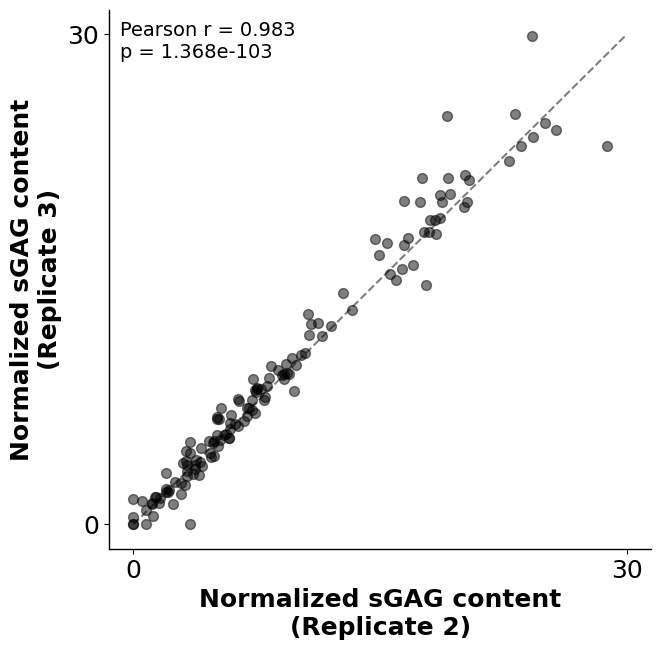

In [44]:
repA = 2
repB = 3

pivoted = dmmb_results.pivot_table(
    index='sample_id',
    columns='replicate',
    values='normalized_value',
    aggfunc='first'
).dropna(subset=[repA, repB])

pearson_corr, pearson_p = pearsonr(pivoted[repA], pivoted[repB])
print(f"Pearson correlation (replicate {repA} vs {repB}): r = {pearson_corr:.3f}, p = {pearson_p:.3e}")

plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    pivoted[repA],
    pivoted[repB],
    c='black',
    s=50,
    alpha=0.5
)

# Set ticks to min and max values
plt.xticks([0, 30])
plt.yticks([0, 30])

plt.plot([0, 30], [0, 30], 'k--', alpha=0.5, linewidth=1.5, label='y=x')

# Add Pearson stats to figure
plt.text(
    0.02, 0.98,
    f"Pearson r = {pearson_corr:.3f}\np = {pearson_p:.3e}",
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    fontsize=FONT_SIZE_small - 4,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

plt.xlabel(f'Normalized sGAG content\n(Replicate {str(repA)})', fontsize=FONT_SIZE_small)
plt.ylabel(f'Normalized sGAG content\n(Replicate {str(repB)})', fontsize=FONT_SIZE_small)

save_fig(plt,f'DMMB_scatterplot_replicate{str(repA)}_vs_replicate{str(repB)}',output_path)

plt.show()

## Collapse data based on replicates (for each sample, takes the mean for all three reps)
dmmb_resutls is the variable containing dmmb values collapsed by rep

In [45]:
# Collapse dmmb_results to one row per sample_id
collapse_cols = [c for c in dmmb_results.columns if c not in ['replicate', 'normalized_value']]

dmmb_collapsed = (
    dmmb_results
    .groupby('sample_id', as_index=False)
    .agg(
        {col: 'first' for col in collapse_cols if col != 'sample_id'}
        | {'normalized_value': 'mean'}
    )
)

# Calculate SE for each sample across the 3 replicates
se_list = []
for sample_id in dmmb_collapsed['sample_id']:
    values = dmmb_results[dmmb_results['sample_id'] == sample_id]['normalized_value'].values
    se = np.std(values, ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0
    se_list.append(se)

dmmb_collapsed['SE'] = se_list

# Reorder columns to keep sample_id first
dmmb_collapsed = dmmb_collapsed[['sample_id', 'SE'] + [c for c in dmmb_collapsed.columns if c not in ['sample_id', 'SE']]]

print(f"Original rows: {len(dmmb_results)}")
print(f"Collapsed rows: {len(dmmb_collapsed)}")

# Test: each sample_id should have exactly 3 rows in the original data and 1 row after collapsing
orig_counts = dmmb_results.groupby('sample_id').size()
collapsed_counts = dmmb_collapsed.groupby('sample_id').size()

assert (orig_counts == 3).all(), "Not all sample_ids have exactly 3 rows in dmmb_results"
assert (collapsed_counts == 1).all(), "Not all sample_ids were collapsed to exactly 1 row"
assert len(dmmb_collapsed) == dmmb_results['sample_id'].nunique(), "Collapsed dataframe has unexpected row count"

print("✓ PASS: each sample_id had 3 rows and was collapsed to 1 row")

Original rows: 417
Collapsed rows: 139
✓ PASS: each sample_id had 3 rows and was collapsed to 1 row


## SE statistics after collapsing

In [46]:
# Print SE statistics (ignoring 0s)
se_values = dmmb_collapsed['SE'].values
se_nonzero = se_values[se_values > 0]

print(f"Max SE: {se_nonzero.max():.6f}")
print(f"Min SE (ignoring 0s): {se_nonzero.min():.6f}")
print(f"Average SE: {se_nonzero.mean():.6f}")
print(f"Number of samples with SE=0: {(se_values == 0).sum()}")
print(f"Number of samples with SE>0: {len(se_nonzero)}")


Max SE: 5.948082
Min SE (ignoring 0s): 0.022350
Average SE: 0.494667
Number of samples with SE=0: 2
Number of samples with SE>0: 137


# Statisticss

In [47]:
# Summary statistics for dmmb_ind_collapsed

print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# 1. All samples
print("\n1. ALL SAMPLES")
print("-" * 80)
n_samples_all = dmmb_collapsed['sample_id'].nunique()
n_individuals_all = dmmb_collapsed['individual'].nunique()
n_males_all = (dmmb_collapsed['sex'] == 'M').sum()
n_females_all = (dmmb_collapsed['sex'] == 'F').sum()
avg_age_all = dmmb_collapsed['age'].mean()

print(f"Number of samples: {n_samples_all}")
print(f"Number of individuals: {n_individuals_all}")
print(f"Number of males: {n_males_all}")
print(f"Number of females: {n_females_all}")
print(f"Average age: {avg_age_all:.2f} years")

# 2. Human samples only
print("\n2. HUMAN SAMPLES")
print("-" * 80)
human_data = dmmb_collapsed[dmmb_collapsed['species'] == 'H']
n_samples_human = human_data['sample_id'].nunique()
n_individuals_human = human_data['individual'].nunique()
n_males_human = (human_data['sex'] == 'M').sum()
n_females_human = (human_data['sex'] == 'F').sum()
avg_age_human = human_data['age'].mean()

print(f"Number of samples: {n_samples_human}")
print(f"Number of individuals: {n_individuals_human}")
print(f"Number of males: {n_males_human}")
print(f"Number of females: {n_females_human}")
print(f"Average age: {avg_age_human:.2f} years")

# 3. Non-human samples only
print("\n3. NON-HUMAN SAMPLES (APES)")
print("-" * 80)
nonhuman_data = dmmb_collapsed[dmmb_collapsed['species'] != 'H']
n_samples_nonhuman = nonhuman_data['sample_id'].nunique()
n_individuals_nonhuman = nonhuman_data['individual'].nunique()
n_males_nonhuman = (nonhuman_data['sex'] == 'M').sum()
n_females_nonhuman = (nonhuman_data['sex'] == 'F').sum()
avg_age_nonhuman = nonhuman_data['age'].mean()

print(f"Number of samples: {n_samples_nonhuman}")
print(f"Number of individuals: {n_individuals_nonhuman}")
print(f"Number of males: {n_males_nonhuman}")
print(f"Number of females: {n_females_nonhuman}")
print(f"Average age: {avg_age_nonhuman:.2f} years")

# 4. Samples and individuals per species
print("\n4. SAMPLES AND INDIVIDUALS PER SPECIES")
print("-" * 80)
species_summary = dmmb_collapsed.groupby('species_name').agg({
    'sample_id': 'nunique',
    'individual': 'nunique',
    'sex': lambda x: (x == 'M').sum(),
}).rename(columns={'sample_id': 'n_samples', 'individual': 'n_individuals', 'sex': 'n_males'})

# Add females
species_summary['n_females'] = dmmb_collapsed.groupby('species_name')['sex'].apply(lambda x: (x == 'F').sum())

# Add average age
species_summary['avg_age'] = dmmb_collapsed.groupby('species_name')['age'].mean()

print(species_summary.to_string())

print("\n" + "=" * 80)

SUMMARY STATISTICS

1. ALL SAMPLES
--------------------------------------------------------------------------------
Number of samples: 139
Number of individuals: 49
Number of males: 68
Number of females: 71
Average age: 68.79 years

2. HUMAN SAMPLES
--------------------------------------------------------------------------------
Number of samples: 111
Number of individuals: 42
Number of males: 53
Number of females: 58
Average age: 77.64 years

3. NON-HUMAN SAMPLES (APES)
--------------------------------------------------------------------------------
Number of samples: 28
Number of individuals: 7
Number of males: 15
Number of females: 13
Average age: 35.89 years

4. SAMPLES AND INDIVIDUALS PER SPECIES
--------------------------------------------------------------------------------
              n_samples  n_individuals  n_males  n_females    avg_age
species_name                                                         
Bonobo                4              1        4          0  24.00000

## Show statistics about samples

In [48]:
# Create a per individual metadata table
individual_metadata = dmmb_collapsed.groupby('individual').agg({
    'species_name': 'first',
    'sex': 'first',
    'age': 'first',
    'notes': 'first'
}).reset_index()

#save to csv
individual_metadata.to_csv(os.path.join('/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/dmmb/', 'dmmb_individual_metadata.csv'), index=False)

In [49]:
# Create paper supplementary table for dmmb results
dmmb_collapsed.to_csv(os.path.join('/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/dmmb/', 'dmmb_collapsed_results.csv'), index=False)

In [51]:
dmmb_collapsed.to_csv(f'{output_path}dmmb_collapsed.csv', index=False)
print(f"✓ Saved dmmb_collapsed to {output_path}dmmb_collapsed.csv")

✓ Saved dmmb_collapsed to /home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/DMMB_boxplots/dmmb_collapsed.csv


In [52]:
import plotly.graph_objects as go

# Filter for non-human samples only
sankey_data_nonhuman = dmmb_collapsed[dmmb_collapsed['species_name'] != 'Human'].copy()

# Color mapping for species (excluding Human)
species_colors_nonhuman = {
    'Chimpanzee': '#F8AC26',
    'Gorilla': '#685599',
    'Bonobo': '#D16D92',
    'Orangutan': '#DD6136'
}

# Aggregate flows: Individual -> Anatomical Region -> Origin in Joint
flows_nonhuman = sankey_data_nonhuman.groupby(['individual', 'anatomical_region', 'origin_in_joint']).size().reset_index(name='count')

# Create node lists
individuals = sorted(flows_nonhuman['individual'].unique())
regions = sorted(flows_nonhuman['anatomical_region'].unique())
origins = sorted(flows_nonhuman['origin_in_joint'].unique())

# Create all nodes (individuals first, then regions, then origins)
all_nodes_nonhuman = individuals + regions + origins
node_indices_nonhuman = {node: i for i, node in enumerate(all_nodes_nonhuman)}

# Prepare source, target, and value lists for Sankey
source_indices_nh = []
target_indices_nh = []
values_nh = []
link_colors_nh = []

# Create color mapping with transparency for species
species_color_map_nh = {
    'Chimpanzee': 'rgba(245, 175, 76, 0.5)',
    'Gorilla': 'rgba(214, 39, 40, 0.5)',
    'Bonobo': 'rgba(44, 160, 44, 0.5)',
    'Orangutan': 'rgba(148, 103, 189, 0.5)'
}

# Get species for each individual
individual_to_species = sankey_data_nonhuman.drop_duplicates('individual')[['individual', 'species_name']].set_index('individual')['species_name']

# Build source, target, values, and colors
for _, row in flows_nonhuman.iterrows():
    ind_idx = node_indices_nonhuman[row['individual']]
    region_idx = node_indices_nonhuman[row['anatomical_region']]
    origin_idx = node_indices_nonhuman[row['origin_in_joint']]
    
    # Individual -> Region
    source_indices_nh.append(ind_idx)
    target_indices_nh.append(region_idx)
    values_nh.append(row['count'])
    link_colors_nh.append(species_color_map_nh[individual_to_species[row['individual']]])
    
    # Region -> Origin
    source_indices_nh.append(region_idx)
    target_indices_nh.append(origin_idx)
    values_nh.append(row['count'])
    link_colors_nh.append(species_color_map_nh[individual_to_species[row['individual']]])

# Create node colors (white boxes)
node_colors_nh = ['white' for _ in all_nodes_nonhuman]

# Create the Sankey diagram
fig_nh = go.Figure(data=[go.Sankey(
    node=dict(
        pad=8,
        thickness=50,
        line=dict(color='black', width=1),
        label=all_nodes_nonhuman,
        color=node_colors_nh,
        customdata=[f"{node}" for node in all_nodes_nonhuman],
        hovertemplate='%{customdata}<br>Total: %{value}<extra></extra>'
    ),
    link=dict(
        source=source_indices_nh,
        target=target_indices_nh,
        value=values_nh,
        color=link_colors_nh,
        hovertemplate='%{source.label} → %{target.label}<br>Count: %{value}<extra></extra>'
    )
)])

fig_nh.update_layout(
    font=dict(size=50),
    height=2000,
    width=2000,
    plot_bgcolor=None,
    margin=dict(l=0, r=0, t=0, b=0)
)

# Display the plot
fig_nh.show()


# Print summary
print("\nAlluvial Plot Summary: Individual → Anatomical Region → Origin in Joint (Non-Human)")
print("=" * 90)
print(f"\nTotal non-human samples: {len(sankey_data_nonhuman)}")
print(f"\nIndividuals ({len(individuals)}): {', '.join(individuals)}")
print(f"Regions ({len(regions)}): {', '.join(regions)}")
print(f"Origins ({len(origins)}): {', '.join(origins)}")
print(f"\nFlows by Species:")
summary_nh = sankey_data_nonhuman['species_name'].value_counts()
for species, count in summary_nh.items():
    print(f"  {species}: {count} samples")


Alluvial Plot Summary: Individual → Anatomical Region → Origin in Joint (Non-Human)

Total non-human samples: 28

Individuals (7): 112_Maaike, 113_Karibana, 114_Marlene, 115_Kirembo, 131_Bokito, 137_Moni, Shoshi
Regions (6): elbow, hip, knee, phalanges, shoulder, wrist
Origins (11): DIP, MCP, PIP, capitulum, femoral head, femur medial condyle, humeral head, radius proximal, schaphoid, tibia proximal, trochlea

Flows by Species:
  Chimpanzee: 19 samples
  Bonobo: 4 samples
  Gorilla: 4 samples
  Orangutan: 1 samples


## Correlation between Weight and DNA content


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


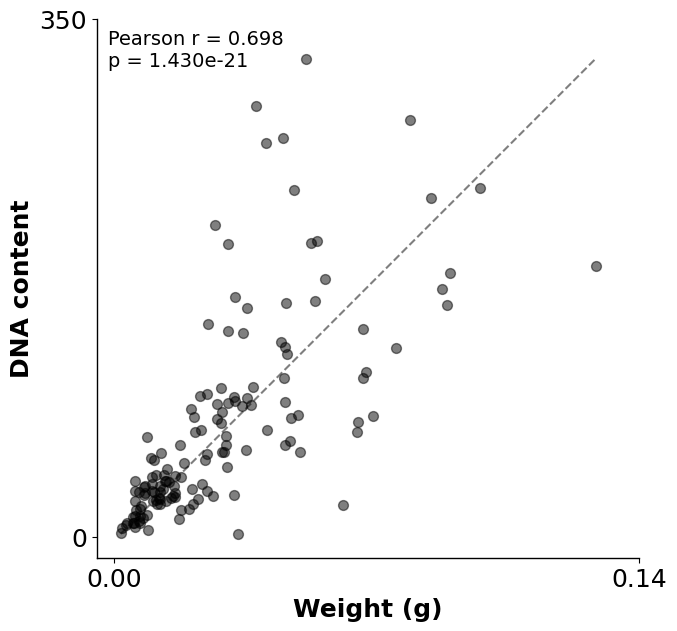

In [53]:
plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    dmmb_collapsed['weight (g)'],
    dmmb_collapsed['DNA'],
    c='black',
    s=50,
    alpha=0.5
)

# Calculate Pearson correlation
pearson_corr, pearson_p = pearsonr(dmmb_collapsed['weight (g)'], dmmb_collapsed['DNA'])

plt.plot(
    [dmmb_collapsed['weight (g)'].min(), dmmb_collapsed['weight (g)'].max()],
    [dmmb_collapsed['DNA'].min(), dmmb_collapsed['DNA'].max()],
    'k--', alpha=0.5, linewidth=1.5, label='y=x'
)

# Add Pearson stats to figure
plt.text(
    0.02, 0.98,
    f"Pearson r = {pearson_corr:.3f}\np = {pearson_p:.3e}",
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    fontsize=FONT_SIZE_small - 4,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

plt.xlabel('Weight (g)', fontsize=FONT_SIZE_small)
plt.ylabel('DNA content', fontsize=FONT_SIZE_small)

ax = plt.gca()
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks([0, xticks[-1]])
ax.set_yticks([0, yticks[-1]])


save_fig(plt, 'DMMB_scatterplot_weight_vs_DNA', output_path)

plt.show()


## Correlation between DNA replicates

In [54]:
dna_rep_1 = [35.47817773, 80.88082033, 96.08300256, 138.6763, 177.8711961, 126.3287749, 128.4584398, 156.4159553, 156.2686912, 229.028465, 64.77239773, 107.0938231]
dna_rep_2 = [35.46466611, 80.72932141, 85.36607874, 143.6406648, 179.0690922, 125.7463829, 92.77138536, 163.4931889, 165.4289226, 205.4941073, 60.85428878, 93.40162422]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


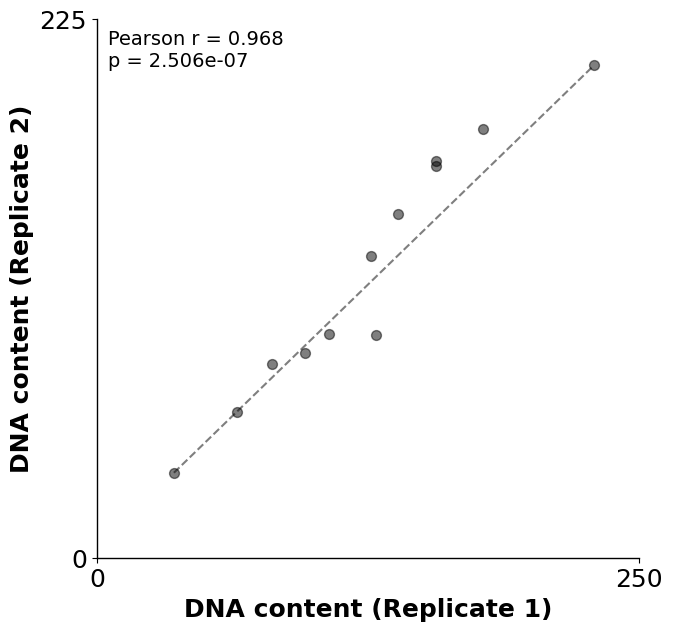

In [55]:
plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    dna_rep_1,
    dna_rep_2,
    c='black',
    s=50,
    alpha=0.5
)

# Calculate Pearson correlation
pearson_corr, pearson_p = pearsonr(dna_rep_1, dna_rep_2)

plt.plot(
    [min(dna_rep_1), max(dna_rep_1)],
    [min(dna_rep_2), max(dna_rep_2)],
    'k--', alpha=0.5, linewidth=1.5, label='y=x'
)

# Add Pearson stats to figure
plt.text(
    0.02, 0.98,
    f"Pearson r = {pearson_corr:.3f}\np = {pearson_p:.3e}",
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    fontsize=FONT_SIZE_small - 4,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

plt.xlabel('DNA content (Replicate 1)', fontsize=FONT_SIZE_small)
plt.ylabel('DNA content (Replicate 2)', fontsize=FONT_SIZE_small)

ax = plt.gca()
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks([0, xticks[-1]])
ax.set_yticks([0, yticks[-1]])


save_fig(plt, 'DNA_correlation_between_replicates', output_path)

plt.show()


## Collapse by individual
dmmb_ind_collapsed is the variable containing dmmb values collapsed by both rep and individual
(of there are several samples in the same joint, collapse them. Even if they are in different parts of the same joint. For example andividual with both trochlea and capitulum will have only one. )

In [56]:
# Collapse rows by individual + joint (anatomical_region only, not origin_in_joint)
group_cols = ['individual', 'anatomical_region']

# identify groups with >1 sample (these will be collapsed)
group_sizes = dmmb_collapsed.groupby(group_cols).size().reset_index(name='count')
dup_groups = group_sizes[group_sizes['count'] > 1]

if dup_groups.empty:
    print("No duplicated individual+joint groups found. Nothing to collapse.")
else:
    individuals_collapsed = sorted([str(x) for x in dup_groups['individual'].unique().tolist()])
    print(f"Found {len(dup_groups)} groups to collapse across {len(individuals_collapsed)} individuals.")
    print("Individuals collapsed:", individuals_collapsed)

    # verify that all non-aggregated columns are identical within each group
    agg_numeric = ['weight (g)', 'DNA', 'normalized_value', 'origin_in_joint']
    cols_to_check = [c for c in dmmb_collapsed.columns if c not in (['sample_id'] + agg_numeric)]
    inconsistencies = []

    for _, row in dup_groups.iterrows():
        mask = (dmmb_collapsed['individual'] == row['individual']) & \
               (dmmb_collapsed['anatomical_region'] == row['anatomical_region'])
        grp = dmmb_collapsed.loc[mask, cols_to_check]
        for col in cols_to_check:
            # treat NaNs: consider them identical only if all are NaN
            nunique = grp[col].dropna().nunique()
            if nunique > 1:
                inconsistencies.append({
                    'group': (row['individual'], row['anatomical_region']),
                    'column': col,
                    'values': grp[col].tolist()
                })

    if inconsistencies:
        print(f"WARNING: Found {len(inconsistencies)} metadata inconsistencies across groups.")
        for inc in inconsistencies:
            ind, joint = inc['group']
            print(f" - Individual {ind}, {joint}: column '{inc['column']}' has differing values -> {inc['values']}")
        print("Proceeding with collapse by taking the first value for non-aggregated columns.")

    # aggregation: sum weight and DNA, mean normalized_value, mean origin_in_joint, concatenate sample_ids, take first for others
    agg_map = {}
    for col in dmmb_collapsed.columns:
        if col == 'sample_id':
            agg_map[col] = lambda x: ','.join(map(str, x))
        elif col in ['weight (g)', 'DNA', 'normalized_value']:
            agg_map[col] = 'mean'
        elif col == 'origin_in_joint':
            agg_map[col] = lambda x: '_'.join(map(str, pd.unique(x.dropna()))) if x.notna().any() else np.nan
        else:
            agg_map[col] = 'first'

    dmmb_ind_collapsed = (
        dmmb_collapsed
        .groupby(group_cols, as_index=False)
        .agg(agg_map)
    )

    # reorder columns to put individual/joint first
    cols_order = group_cols + [c for c in dmmb_ind_collapsed.columns if c not in group_cols]
    dmmb_ind_collapsed = dmmb_ind_collapsed[cols_order]

    print(f"Original rows: {len(dmmb_collapsed)}")
    print(f"Collapsed rows: {len(dmmb_ind_collapsed)}")
    print(f"Number of groups collapsed: {len(dup_groups)}")
    print("Collapsed individuals (unique):", individuals_collapsed)

    # make collapsed df available in the notebook
    dmmb_ind_collapsed = dmmb_ind_collapsed.copy()


Found 35 groups to collapse across 32 individuals.
Individuals collapsed: ['112_Maaike', '113_Karibana', '115_Kirembo', '131_Bokito', '2023ST3', '240460', '240463', '240732', '240808', '241392', '250113', 'SN1', 'SN10', 'SN11', 'SN12', 'SN2', 'SN27', 'SN28', 'SN29', 'SN3', 'SN30', 'SN31', 'SN32', 'SN33', 'SN35', 'SN4', 'SN5', 'SN6', 'SN7', 'SN8', 'SN9', 'Shoshi']
 - Individual 240460, elbow: column 'SE' has differing values -> [0.053413576821000945, 0.03128001564593801]
 - Individual 240460, elbow: column 'description' has differing values -> ['Elbow - capitulum', 'Elbow - trochlea']
 - Individual 240460, elbow: column 'weight (micro g)' has differing values -> [28500.0, 46000.0]
 - Individual 240460, elbow: column 'normalized_value_by_weight' has differing values -> [0.025352047370330633, 0.02430434856000154]
 - Individual 240463, elbow: column 'SE' has differing values -> [0.5600468539885753, 0.500201610015766]
 - Individual 240463, elbow: column 'description' has differing values ->

# combined P-value for all samples, one sample per individual

In [86]:
dmmb_ind_collapsed[~(dmmb_ind_collapsed['species_name'] == 'Human')]

,individual,anatomical_region,sample_id,SE,origin_in_joint,species,age,sex,weight (g),DNA,description,notes,remove from analysis,species_name,weight (micro g),normalized_value_by_weight,Maximum longevity (yrs),age_adjustment_longevity,age_adjustment_charvet,normalized_value
15,112_Maaike,elbow,"B18,B19",0.621220,radius proximal_capitulum,C,37.0,F,0.031465,72.784688,Elbow - radius proximal,None,NaN,Chimpanzee,28880.0,0.046122,68.0,0.544118,47.201532,19.510319
16,112_Maaike,shoulder,B20,0.225143,humeral head,C,37.0,F,0.027420,79.623130,Shoulder - humeral head,None,NaN,Chimpanzee,27420.0,0.054632,68.0,0.544118,47.201532,18.498812
17,113_Karibana,elbow,"B11,B9",0.340809,radius proximal_capitulum,C,20.0,M,0.055285,69.914475,Elbow - radius proximal,None,NaN,Chimpanzee,65060.0,0.022327,68.0,0.294118,25.576663,21.135787
18,113_Karibana,hip,B2,2.021712,femoral head,C,20.0,M,0.029800,68.136051,Hip - femoral head,None,NaN,Chimpanzee,29800.0,0.031937,68.0,0.294118,25.576663,18.000913
19,113_Karibana,knee,"B3,B4",0.749755,femur medial condyle_tibia proximal,C,20.0,M,0.055880,67.802711,Knee - femur medial condyle,None,NaN,Chimpanzee,46900.0,0.029787,68.0,0.294118,25.576663,19.860673
20,113_Karibana,shoulder,B8,0.970680,humeral head,C,20.0,M,0.087500,167.140359,Shoulder - humeral head,None,NaN,Chimpanzee,87500.0,0.033001,68.0,0.294118,25.576663,16.569308
21,113_Karibana,wrist,B7,1.471920,schaphoid,C,20.0,M,0.045700,90.886182,Wrist - schaphoid,None,NaN,Chimpanzee,45700.0,0.023133,68.0,0.294118,25.576663,14.549333
22,114_Marlene,elbow,B30,0.280440,capitulum,C,41.0,F,0.066320,140.255053,Elbow - humeral condyle radial part,None,NaN,Chimpanzee,66320.0,0.022587,68.0,0.602941,52.289737,11.239524
23,114_Marlene,wrist,B31,0.602923,schaphoid,C,41.0,F,0.045230,107.469636,Wrist - schaphoid,None,NaN,Chimpanzee,45230.0,0.020170,68.0,0.602941,52.289737,9.690386
24,115_Kirembo,elbow,"B14,B17",0.389160,radius proximal_capitulum,B,24.0,M,0.048160,81.100587,Elbow - radius proximal,None,NaN,Bonobo,49020.0,0.035736,55.0,0.436364,35.609579,19.226032


In [68]:
dmmb_ind_collapsed_for_all_joints = dmmb_ind_collapsed.copy()
dmmb_ind_collapsed_for_all_joints = dmmb_ind_collapsed_for_all_joints[['individual', 'species_name', 'normalized_value']]

#collapse based on individual, take mean of normalized_value across all joints
dmmb_ind_collapsed_for_all_joints = dmmb_ind_collapsed_for_all_joints.groupby(['individual', 'species_name'], as_index=False).agg({'normalized_value': 'mean'})

In [81]:
HUMAN_dmmb_ind_collapsed_for_all_joints = dmmb_ind_collapsed_for_all_joints[dmmb_ind_collapsed_for_all_joints['species_name'] == 'Human']
NONHUMAN_dmmb_ind_collapsed_for_all_joints = dmmb_ind_collapsed_for_all_joints[dmmb_ind_collapsed_for_all_joints['species_name'] != 'Human']

ttest_ind(HUMAN_dmmb_ind_collapsed_for_all_joints['normalized_value'], NONHUMAN_dmmb_ind_collapsed_for_all_joints['normalized_value'], equal_var=False, nan_policy='omit', alternative='two-sided')
print(f"t-test comparing Human vs Non-Human normalized values (collapsed by individual): {ttest_ind(HUMAN_dmmb_ind_collapsed_for_all_joints['normalized_value'], NONHUMAN_dmmb_ind_collapsed_for_all_joints['normalized_value'], equal_var=False, nan_policy='omit', alternative='two-sided').pvalue}")
#also calculat the overall log FC
mean_human = HUMAN_dmmb_ind_collapsed_for_all_joints['normalized_value'].mean()
mean_nonhuman = NONHUMAN_dmmb_ind_collapsed_for_all_joints['normalized_value'].mean()
fc = mean_nonhuman / mean_human
print(fc)

t-test comparing Human vs Non-Human normalized values (collapsed by individual): 1.4800380668243848e-05
2.670127132855988


# Confounder analysis

## Correlation with age

All samples: Pearson r = -0.686, p = 1.120e-10
  Age - Min: 20.00, Max: 97.00, Mean: 65.35, SD: 23.33


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


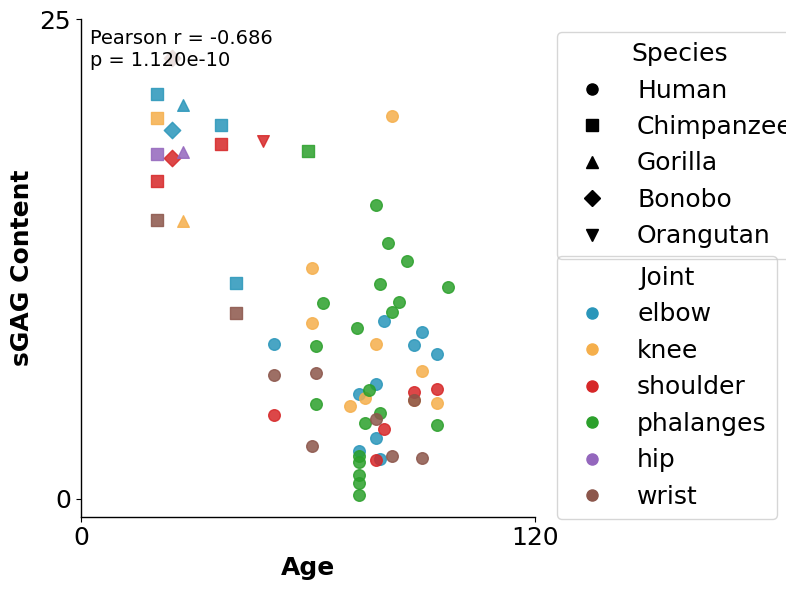

Ape samples: Pearson r = -0.261, p = 3.124e-01
  Age - Min: 20.00, Max: 60.00, Mean: 30.41, SD: 11.72


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


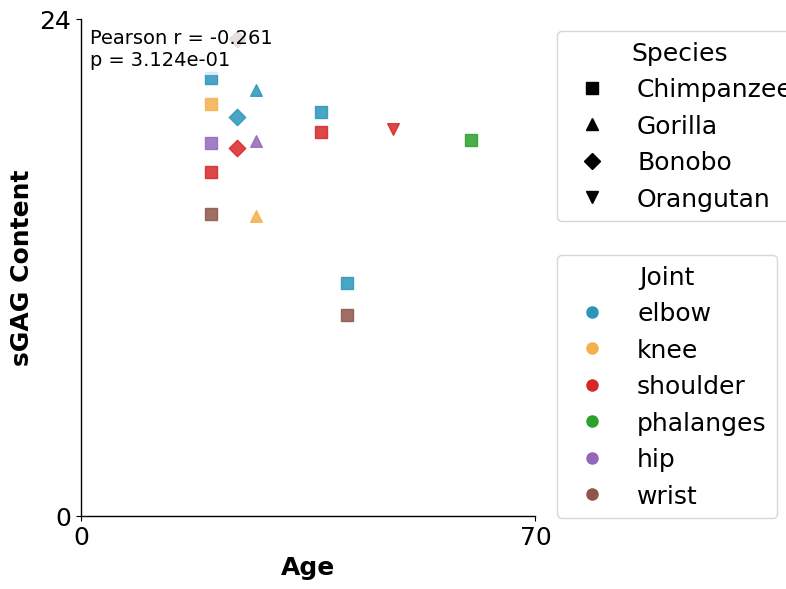

Human samples: Pearson r = 0.068, p = 6.333e-01
  Age - Min: 51.00, Max: 97.00, Mean: 77.00, SD: 11.49


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


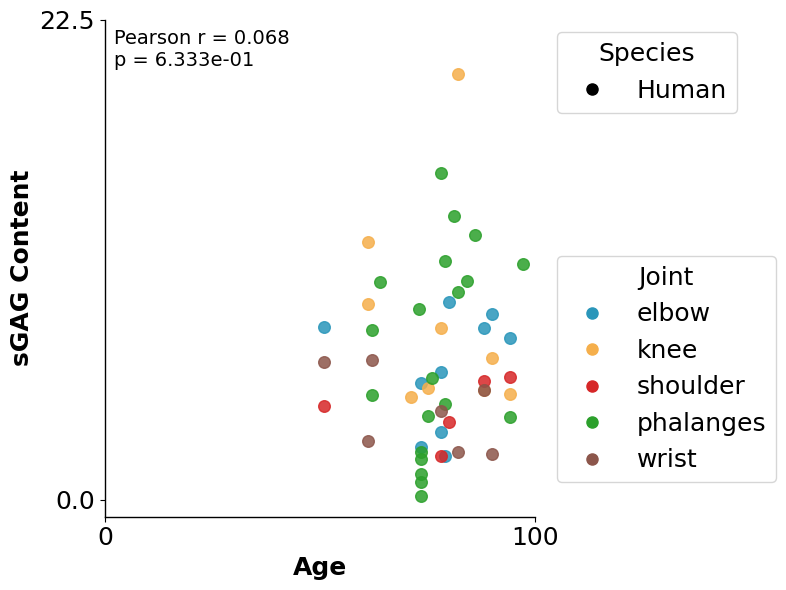

In [90]:
def plot_age_scatter(df, label, filename_suffix, age_method='age',save_figure=True):
    df = df.copy()
    df[age_method] = pd.to_numeric(df[age_method], errors='coerce')
    plot_df = df.dropna(subset=[age_method, 'normalized_value', 'anatomical_region', 'species_name']).copy()
    if plot_df.empty:
        print(f"No data for {label}")
        return

    pearson_corr, pearson_p = pearsonr(plot_df[age_method], plot_df['normalized_value'])
    print(f"{label}: Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
    
    # Print age statistics based on the method
    age_values = plot_df[age_method]
    print(f"  {age_method.replace('_', ' ').title()} - Min: {age_values.min():.2f}, Max: {age_values.max():.2f}, Mean: {age_values.mean():.2f}, SD: {age_values.std():.2f}")

    species_markers = {
        'Human': 'o',
        'Chimpanzee': 's',
        'Gorilla': '^',
        'Bonobo': 'D',
        'Orangutan': 'v'
    }
    region_colors = {
        'elbow': '#2A96BA',
        'knee': '#F5AF4C',
        'shoulder': '#D62728',
        'phalanges': '#2CA02C',
        'hip': '#9467BD',
        'wrist': '#8C564B',
    }

    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    for species_name in sorted(plot_df['species_name'].unique()):
        for region in sorted(plot_df['anatomical_region'].unique()):
            subset = plot_df[(plot_df['species_name'] == species_name) & (plot_df['anatomical_region'] == region)]
            if not subset.empty:
                ax.scatter(
                    subset[age_method],
                    subset['normalized_value'],
                    marker=species_markers.get(species_name, 'o'),
                    s=70,
                    alpha=0.85,
                    color=region_colors.get(region, '#AEAEAE')
                )

    ax.text(
        0.02, 0.98,
        f"Pearson r = {pearson_corr:.3f}\np = {pearson_p:.3e}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=FONT_SIZE_small - 4,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    species_handles = [
        matplotlib.lines.Line2D([0], [0], marker=marker, color='black', linestyle='None',
                                markersize=8, label=species_name)
        for species_name, marker in species_markers.items()
        if species_name in plot_df['species_name'].unique()
    ]
    region_handles = [
        matplotlib.lines.Line2D([0], [0], marker='o', color=color, linestyle='None',
                                markersize=8, label=region)
        for region, color in region_colors.items()
        if region in plot_df['anatomical_region'].unique()
    ]

    leg1 = ax.legend(handles=species_handles, title='Species', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.add_artist(leg1)
    ax.legend(handles=region_handles, title='Joint', bbox_to_anchor=(1.02, 0.55), loc='upper left')

    ax.set_xlabel(age_method.replace('_', ' ').title(), fontsize=FONT_SIZE_small)
    ax.set_ylabel('sGAG Content', fontsize=FONT_SIZE_small)

    ax = plt.gca()
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    ax.set_xticks([0, xticks[-1]])
    ax.set_yticks([0, yticks[-1]])

    plt.tight_layout()
    if save_figure:
        save_fig(plt, f'DMMB_scatterplot_{age_method}_vs_normalized_value_{filename_suffix}', output_path)
    plt.show()

plot_age_scatter(dmmb_ind_collapsed, 'All samples', 'all')
plot_age_scatter(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] != 'Human'], 'Ape samples', 'ape')
plot_age_scatter(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] == 'Human'], 'Human samples', 'human')

All samples: Pearson r = -0.616, p = 2.320e-08
  Age Adjustment Charvet - Min: 25.58, Max: 97.00, Mean: 68.11, SD: 19.84


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


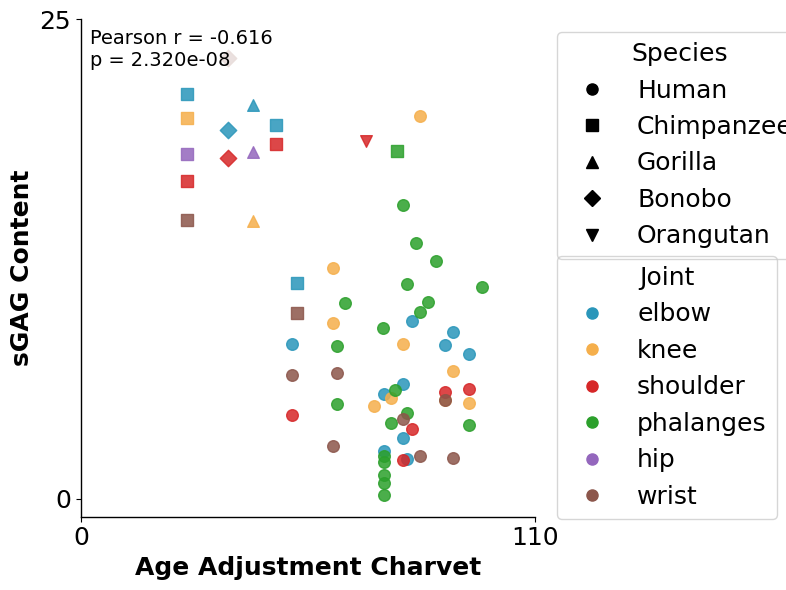

Ape samples: Pearson r = -0.201, p = 4.399e-01
  Age Adjustment Charvet - Min: 25.58, Max: 76.46, Mean: 41.43, SD: 15.10


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


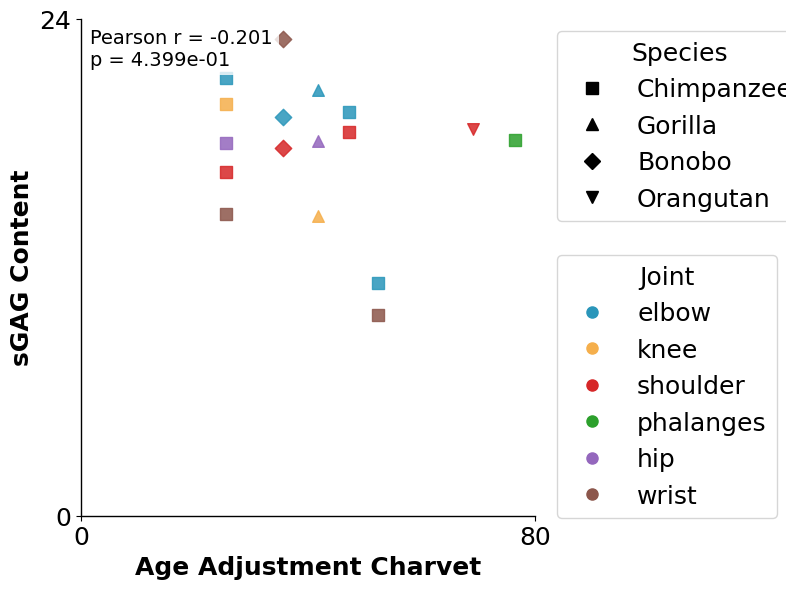

Human samples: Pearson r = 0.068, p = 6.333e-01
  Age Adjustment Charvet - Min: 51.00, Max: 97.00, Mean: 77.00, SD: 11.49


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


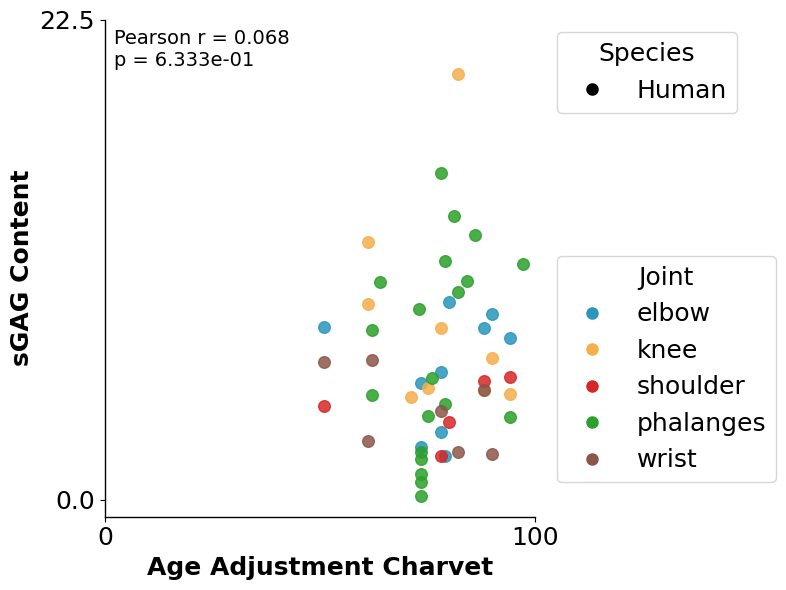

In [86]:
plot_age_scatter(dmmb_ind_collapsed, 'All samples', 'all', age_method='age_adjustment_charvet')
plot_age_scatter(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] != 'Human'], 'Ape samples', 'ape', age_method='age_adjustment_charvet')
plot_age_scatter(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] == 'Human'], 'Human samples', 'human', age_method='age_adjustment_charvet')


All samples: Pearson r = -0.391, p = 9.766e-04
  Age Adjustment Longevity - Min: 0.29, Max: 0.88, Mean: 0.59, SD: 0.14


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


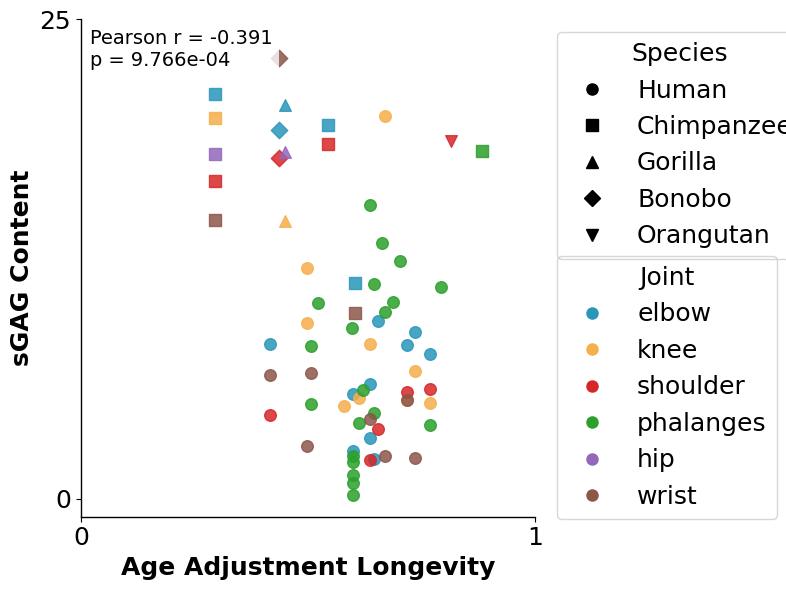

Ape samples: Pearson r = -0.179, p = 4.913e-01
  Age Adjustment Longevity - Min: 0.29, Max: 0.88, Mean: 0.48, SD: 0.18


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


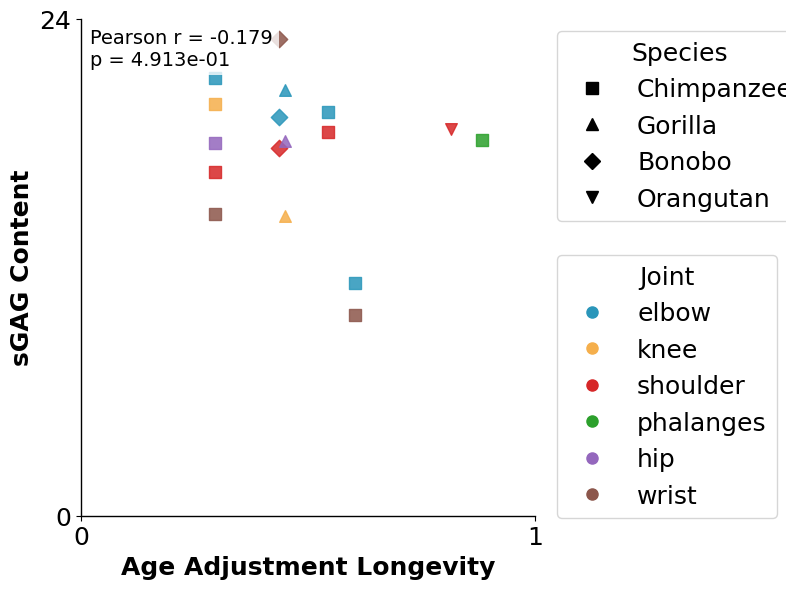

Human samples: Pearson r = 0.068, p = 6.333e-01
  Age Adjustment Longevity - Min: 0.42, Max: 0.79, Mean: 0.63, SD: 0.09


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


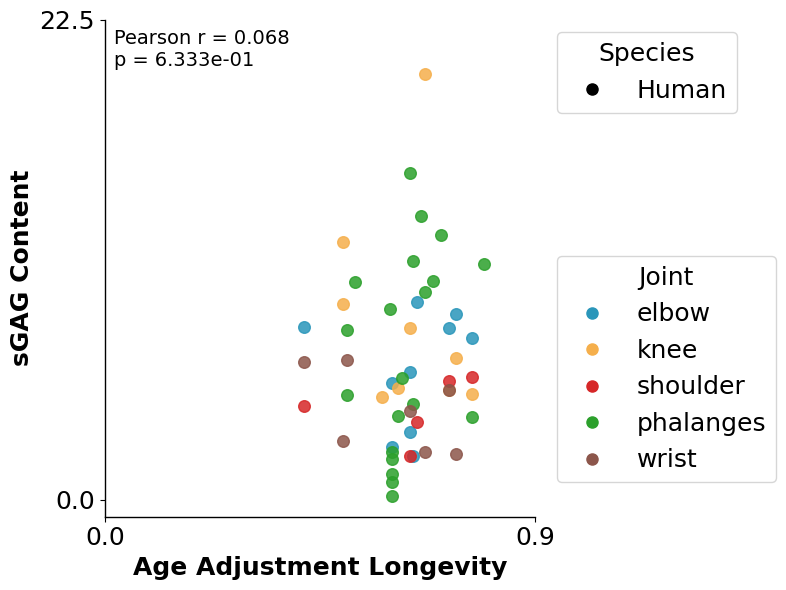

In [87]:
plot_age_scatter(dmmb_ind_collapsed, 'All samples', 'all', age_method='age_adjustment_longevity')
plot_age_scatter(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] != 'Human'], 'Ape samples', 'ape', age_method='age_adjustment_longevity')
plot_age_scatter(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] == 'Human'], 'Human samples', 'human', age_method='age_adjustment_longevity')


## Age correlation per joint

### Human then non-human samples

Elbow samples: Pearson r = 0.146, p = 6.876e-01
  Age - Min: 51.00, Max: 94.00, Mean: 78.48, SD: 11.90


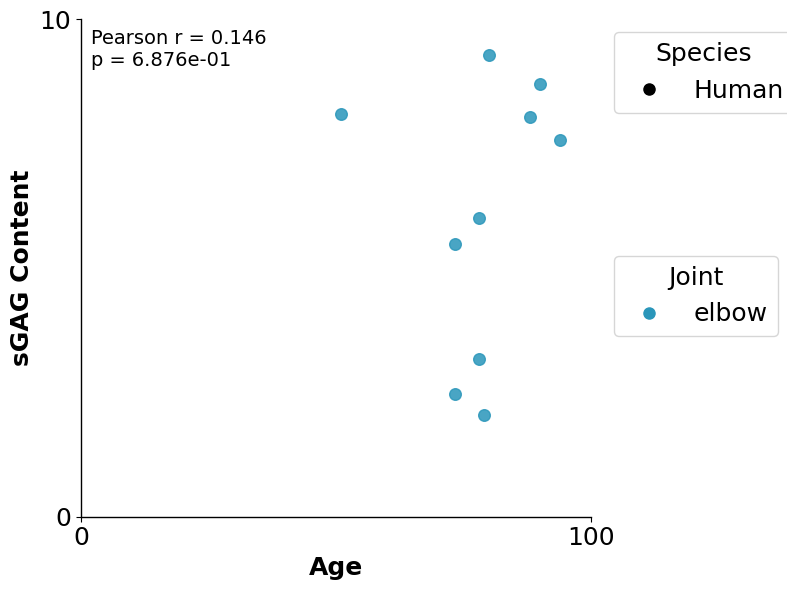

Shoulder samples: Pearson r = 0.319, p = 6.004e-01
  Age - Min: 51.00, Max: 94.00, Mean: 78.20, SD: 16.50


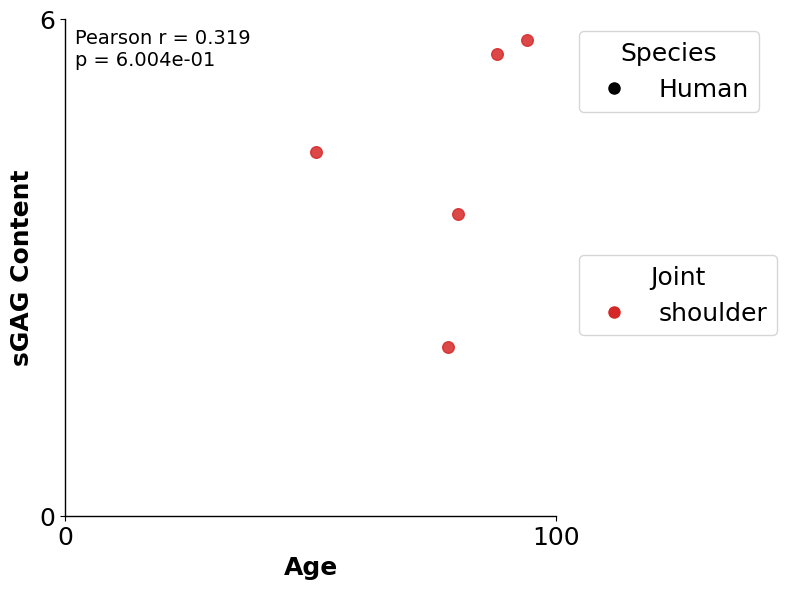

Knee samples: Pearson r = -0.217, p = 5.744e-01
  Age - Min: 61.00, Max: 94.00, Mean: 77.78, SD: 12.00


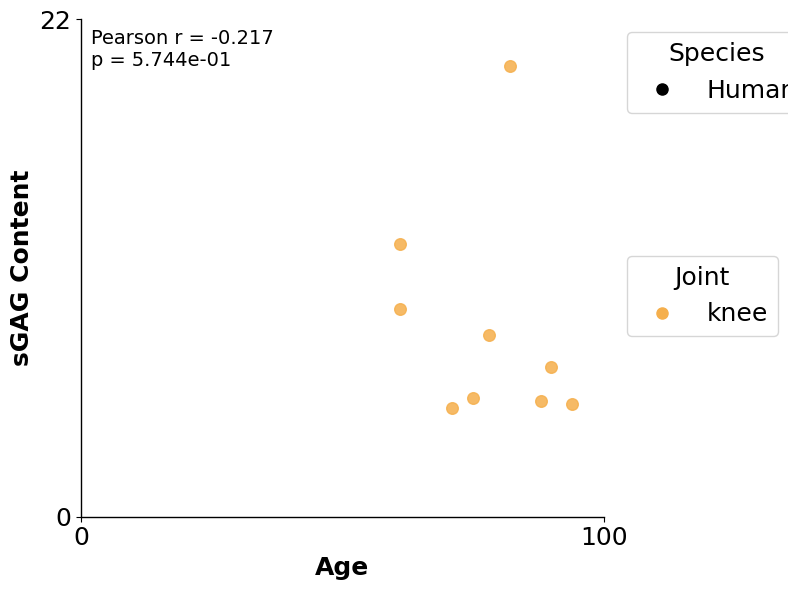

No data for Hip samples
Wrist samples: Pearson r = -0.561, p = 1.897e-01
  Age - Min: 51.00, Max: 90.00, Mean: 73.14, SD: 15.10


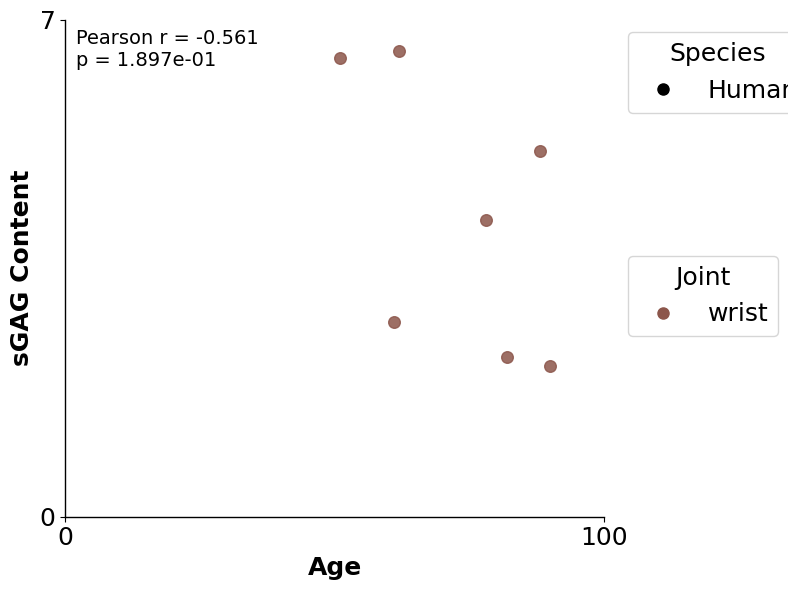

Phalanges samples: Pearson r = 0.285, p = 2.226e-01
  Age - Min: 62.00, Max: 97.00, Mean: 76.95, SD: 9.10


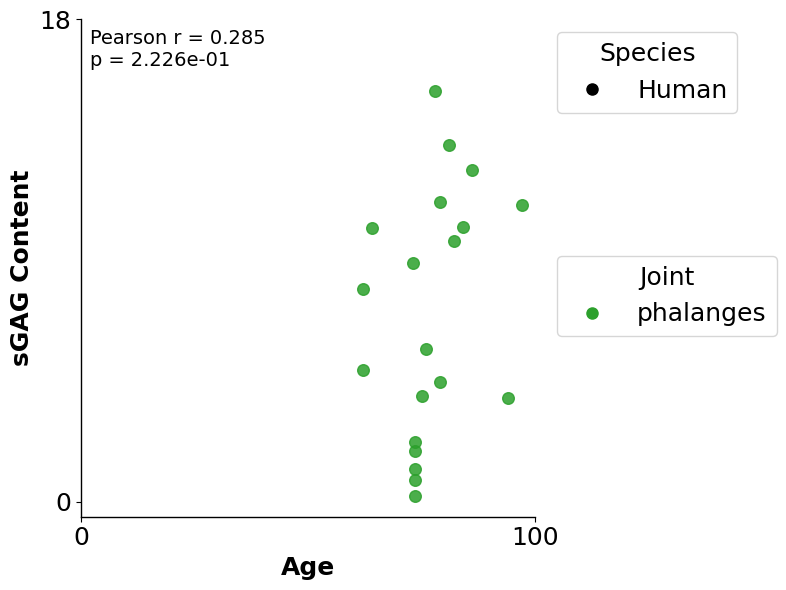

Elbow samples: Pearson r = -0.766, p = 1.309e-01
  Age - Min: 20.00, Max: 41.00, Mean: 29.80, SD: 8.87


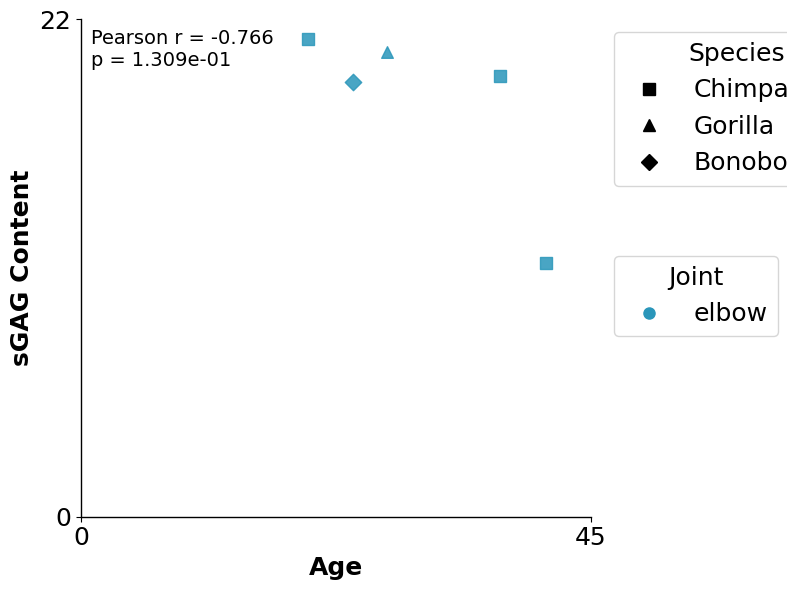

Shoulder samples: Pearson r = 0.884, p = 1.156e-01
  Age - Min: 20.00, Max: 48.00, Mean: 32.25, SD: 12.76


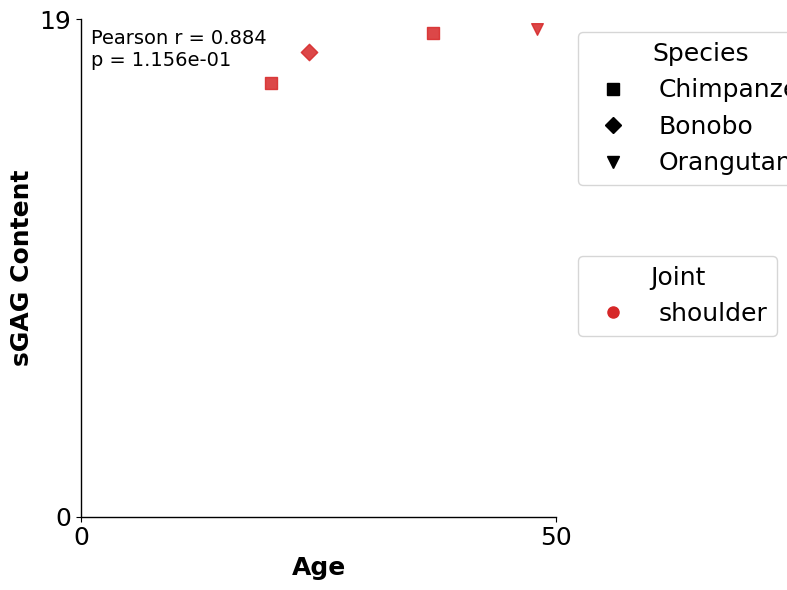

Wrist samples: Pearson r = -0.653, p = 5.466e-01
  Age - Min: 20.00, Max: 41.00, Mean: 28.33, SD: 11.15


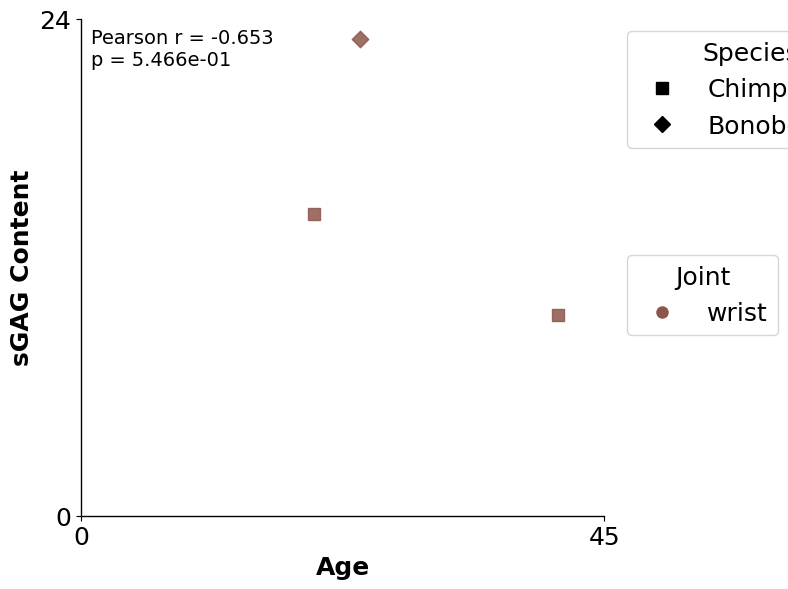

In [98]:
for region in dmmb_ind_collapsed['anatomical_region'].unique():
    if len(dmmb_ind_collapsed[(dmmb_ind_collapsed['anatomical_region'] == region) & (dmmb_ind_collapsed['species'] == 'H')]) >= 3:
        plot_age_scatter(
            dmmb_ind_collapsed[(dmmb_ind_collapsed['anatomical_region'] == region) & (dmmb_ind_collapsed['species'] == 'H')],
            f'{region.capitalize()} samples',
            f'{region}',
            age_method='age',
            save_figure=False
        )

for region in dmmb_ind_collapsed['anatomical_region'].unique():
    if len(dmmb_ind_collapsed[(dmmb_ind_collapsed['anatomical_region'] == region) & (dmmb_ind_collapsed['species'] != 'H')]) >= 3:
        plot_age_scatter(
            dmmb_ind_collapsed[(dmmb_ind_collapsed['anatomical_region'] == region) & (dmmb_ind_collapsed['species'] != 'H')],
            f'{region.capitalize()} samples',
            f'{region}',
            age_method='age',
            save_figure=False
        )

In [138]:
dmmb_ind_collapsed[(dmmb_ind_collapsed['anatomical_region'] == 'shoulder') & (dmmb_ind_collapsed['species'] == 'H')]

,individual,anatomical_region,sample_id,origin_in_joint,species,age,sex,weight (g),DNA,description,notes,remove from analysis,species_name,Maximum longevity (yrs),age_adjustment_longevity,age_adjustment_charvet,normalized_value
1,240460,shoulder,90,humeral head,H,51.0,M,0.0274,89.673414,Shoulder - humeral head,None,NaN,Human,122.5,0.416327,51.0,4.391243
3,240463,shoulder,95,humeral head,H,80.0,F,0.0345,137.531906,Shoulder - humeral head,None,NaN,Human,122.5,0.653061,80.0,3.640044
8,240808,shoulder,94,humeral head,H,88.0,F,0.0321,94.225288,Shoulder - humeral head,None,NaN,Human,122.5,0.718367,88.0,5.572932
11,241392,shoulder,92,humeral head,H,78.0,F,0.0458,157.994070,Shoulder - humeral head,None,NaN,Human,122.5,0.636735,78.0,2.034957
14,250113,shoulder,96,humeral head,H,94.0,M,0.0371,101.382791,Shoulder - humeral head,None,NaN,Human,122.5,0.767347,94.0,5.745880
34,2023ST3,shoulder,93,humeral head,H,NaN,F,0.0535,159.163944,Shoulder - humeral head,None,NaN,Human,122.5,NaN,NaN,4.875197


## Corrected ages

/tmp/ipykernel_3459175/3668731615.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


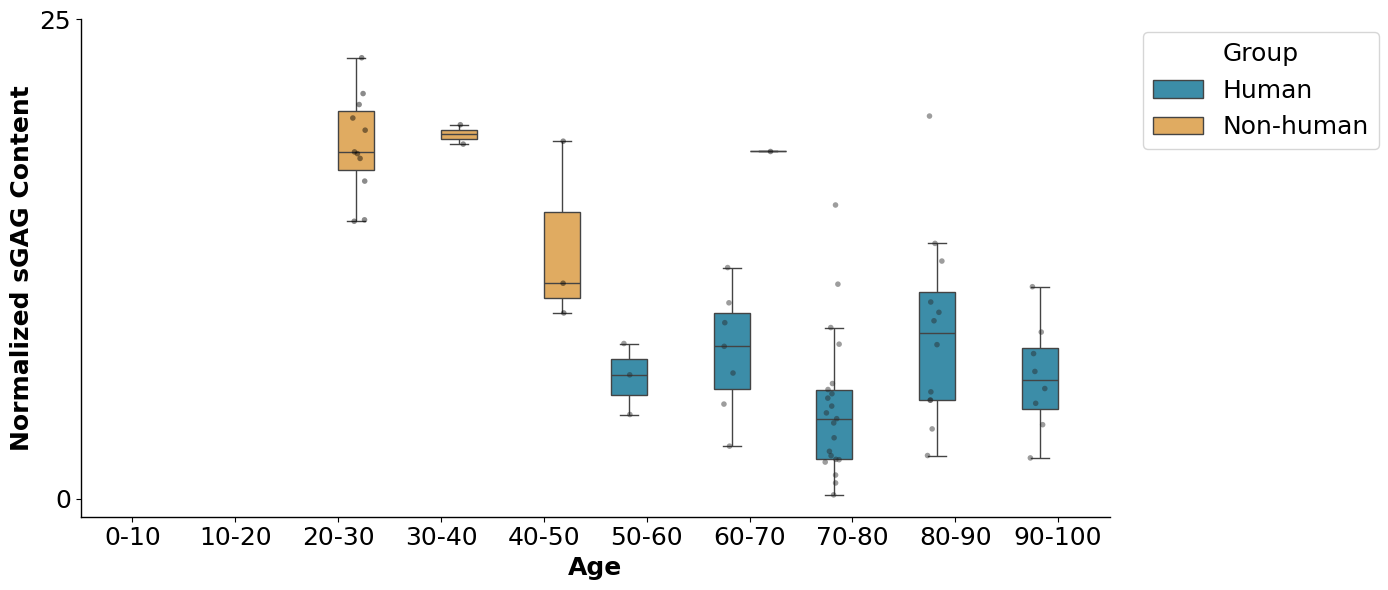

/tmp/ipykernel_3459175/3668731615.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


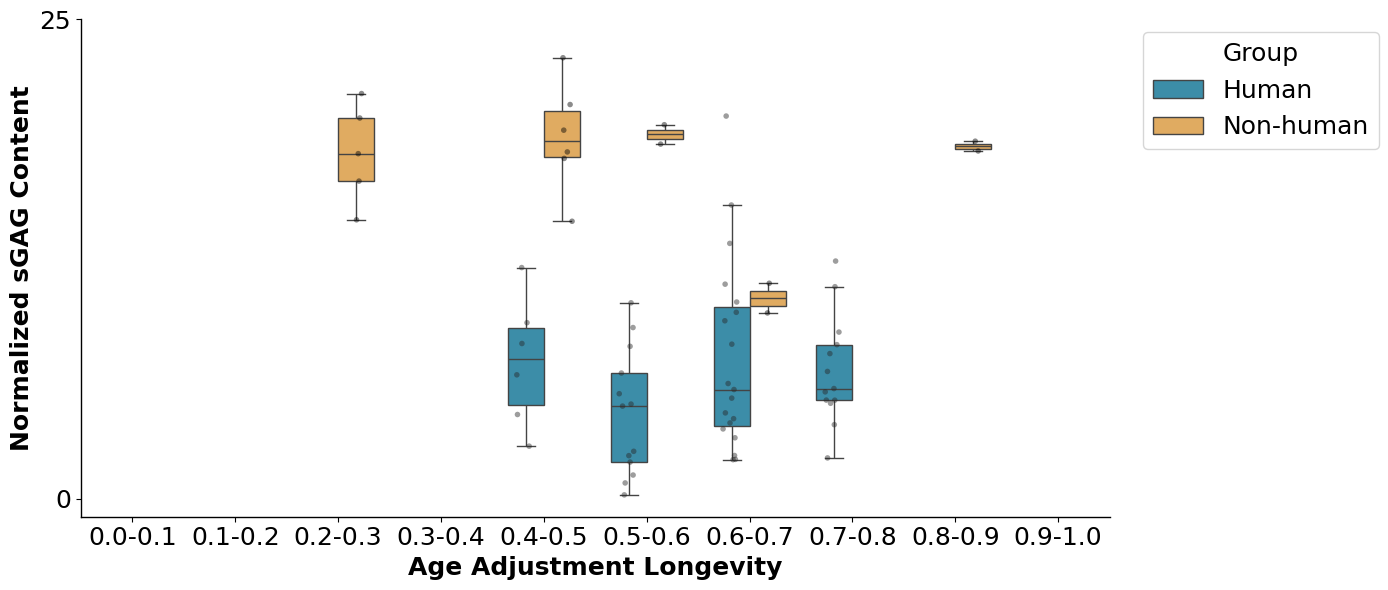

/tmp/ipykernel_3459175/3668731615.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


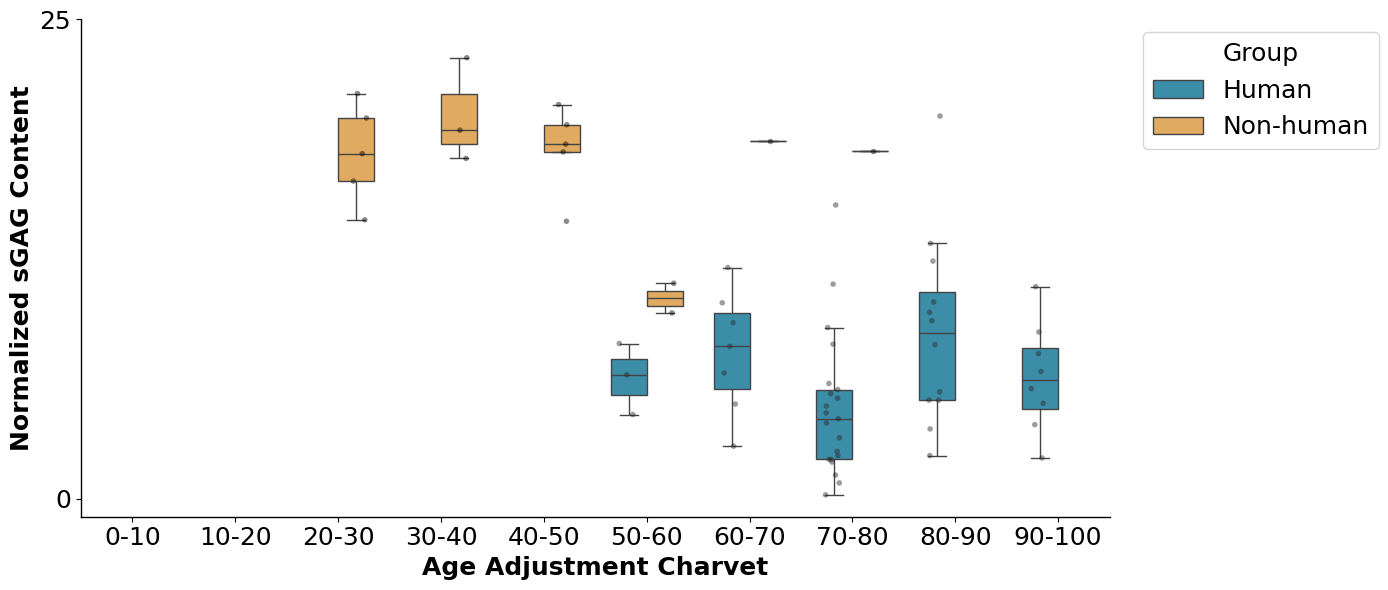

In [36]:
def plot_age_bins_comparison(age_method, bins, labels, filename_suffix):
    plot_df = dmmb_ind_collapsed.copy()
    plot_df['age_numeric'] = pd.to_numeric(plot_df.get(age_method), errors='coerce')
    plot_df['age_bin'] = pd.cut(plot_df['age_numeric'], bins=bins, labels=labels, right=False)
    plot_df['group'] = np.where(plot_df['species'] == 'H', 'Human', 'Non-human')
    plot_df = plot_df.dropna(subset=['age_numeric', 'normalized_value', 'age_bin'])

    if plot_df.empty:
        print(f"No data for {age_method}")
        return

    plt.figure(figsize=(14, 6))
    ax = sns.boxplot(
        data=plot_df,
        x='age_bin',
        y='normalized_value',
        hue='group',
        hue_order=['Human', 'Non-human'],
        palette={'Human': '#2A96BA', 'Non-human': '#F5AF4C'},
        showfliers=False,
        width=0.7
    )

    sns.stripplot(
        data=plot_df,
        x='age_bin',
        y='normalized_value',
        hue='group',
        hue_order=['Human', 'Non-human'],
        dodge=True,
        color='black',
        alpha=0.45,
        jitter=0.15,
        size=4
    )

    handles, labels_ = ax.get_legend_handles_labels()
    if len(handles) >= 2:
        ax.legend(handles[:2], labels_[:2], title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.xlabel(age_method.replace('_', ' ').title(), fontsize=FONT_SIZE_small)
    plt.ylabel('Normalized sGAG Content', fontsize=FONT_SIZE_small)

    ax = plt.gca()
    yticks = ax.get_yticks()
    ax.set_yticks([0, yticks[-1]])

    plt.tight_layout()
    save_fig(plt, f'DMMB_boxplot_by_{filename_suffix}', output_path)
    plt.show()
    plt.close()

# 1) Regular age (years)
age_bins_years = list(range(0, 110, 10))  # 0-100 in 10-year bins
age_labels_years = [f"{i}-{i+10}" for i in range(0, 100, 10)]
plot_age_bins_comparison('age', age_bins_years, age_labels_years, 'age_years_human_vs_nonhuman')

# 2) age_adjustment_longevity (normalized 0-1) — use 0.0-1.0 decile bins
lon_bins = list(np.linspace(0.0, 1.0, 11))
lon_labels = [f"{lon_bins[i]:.1f}-{lon_bins[i+1]:.1f}" for i in range(len(lon_bins)-1)]
plot_age_bins_comparison('age_adjustment_longevity', lon_bins, lon_labels, 'age_longevity_norm_human_vs_nonhuman')

# 3) age_adjustment_charvet (human-equivalent years) — use same year bins as raw age
plot_age_bins_comparison('age_adjustment_charvet', age_bins_years, age_labels_years, 'age_charvet_human_vs_nonhuman')

# Shoshi-specific comparison

In [107]:
from scipy.stats import ttest_ind, mannwhitneyu

shoshi_data = dmmb_ind_collapsed[dmmb_ind_collapsed['individual'] == 'Shoshi'].copy()
female_humans_70_80 = dmmb_ind_collapsed[
    (dmmb_ind_collapsed['species'] == 'H') & 
    (dmmb_ind_collapsed['sex'] == 'F') & 
    (dmmb_ind_collapsed['age'] >= 70) & 
    (dmmb_ind_collapsed['age'] < 80)
].copy()

print("=" * 80)
print("SHOSHI vs FEMALE HUMANS (Age 70-80)")
print("=" * 80)

print(f"\nShoshi data:")
print(f"  Age: {shoshi_data['age'].values[0]}")
print(f"  Species: {shoshi_data['species_name'].values[0]}")
print(f"  n samples: {len(shoshi_data)}")
print(shoshi_data[['anatomical_region', 'origin_in_joint', 'normalized_value', 'age']].to_string(index=False))

print(f"\nFemale humans (age 70-80):")
print(f"  n individuals: {female_humans_70_80['individual'].nunique()}")
print(f"  n samples: {len(female_humans_70_80)}")
print(f"  Age range: {female_humans_70_80['age'].min():.1f} - {female_humans_70_80['age'].max():.1f}")
print(female_humans_70_80[['individual', 'anatomical_region', 'origin_in_joint', 'normalized_value', 'age', 'sex']].to_string(index=False))

# Summary statistics
print(f"\n" + "-" * 80)
print("SUMMARY STATISTICS")
print("-" * 80)

shoshi_values = shoshi_data['normalized_value'].values
female_human_values = female_humans_70_80['normalized_value'].values

print(f"\nShoshi (n={len(shoshi_values)}):")


print(f"\nFemale humans 70-80 (n={len(female_human_values)}):")
print(f"  Mean: {female_human_values.mean():.3f}")
print(f"  Median: {np.median(female_human_values):.3f}")
print(f"  Min-Max: {female_human_values.min():.3f} - {female_human_values.max():.3f}")

fold_change = shoshi_values[0] / np.median(female_human_values)
print(f"  Fold change (Shoshi/Female humans): {fold_change:.3f}x")

SHOSHI vs FEMALE HUMANS (Age 70-80)

Shoshi data:
  Age: 60.0
  Species: Chimpanzee
  n samples: 1
anatomical_region origin_in_joint  normalized_value  age
        phalanges     MCP_PIP_DIP         18.140548 60.0

Female humans (age 70-80):
  n individuals: 9
  n samples: 12
  Age range: 73.0 - 78.0
individual anatomical_region      origin_in_joint  normalized_value  age sex
    241392             elbow   capitulum_trochlea          3.177586 78.0   F
    241392              knee femur medial condyle          8.061411 78.0   F
    241392          shoulder         humeral head          2.034957 78.0   F
241392-St5             wrist            schaphoid          4.173615 78.0   F
      SN14              knee femur medial condyle          5.246128 75.0   F
       SN2             elbow   capitulum_trochlea          5.476393 73.4   F
       SN2         phalanges                  MCP          0.820950 73.4   F
      SN27         phalanges          PIP_DIP_MCP          5.695675 76.0   F
      

# M vs F

All samples: Male samples: 34, Female samples: 40


/tmp/ipykernel_3459175/746518836.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


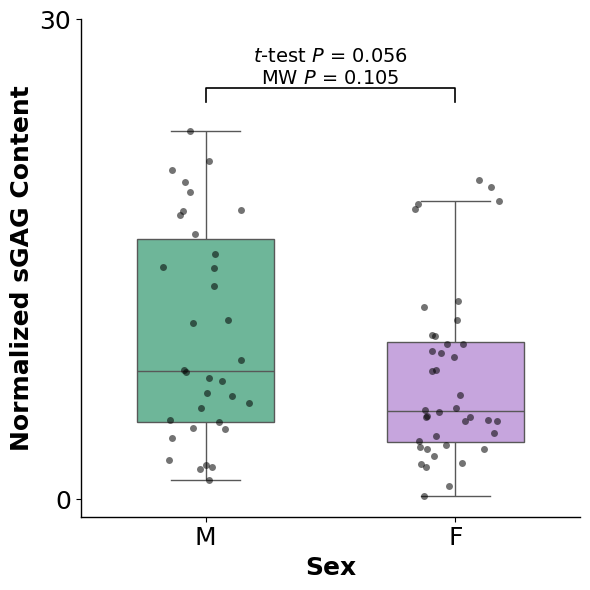

/tmp/ipykernel_3459175/746518836.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Human samples: Male samples: 23, Female samples: 34


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


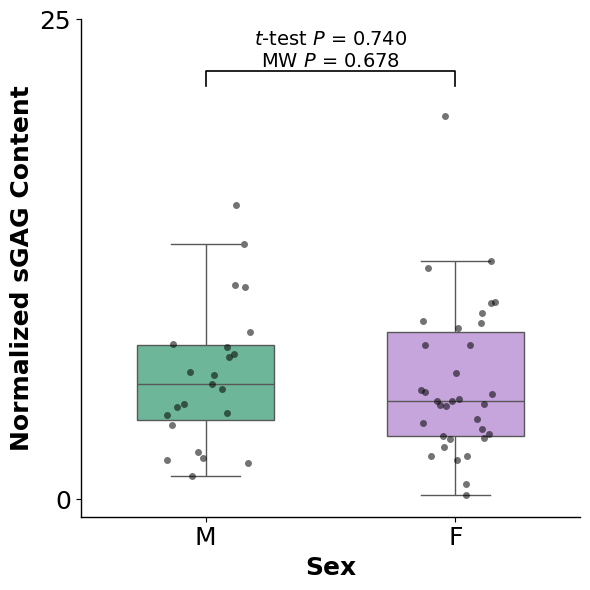

/tmp/ipykernel_3459175/746518836.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Ape samples: Male samples: 11, Female samples: 6


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


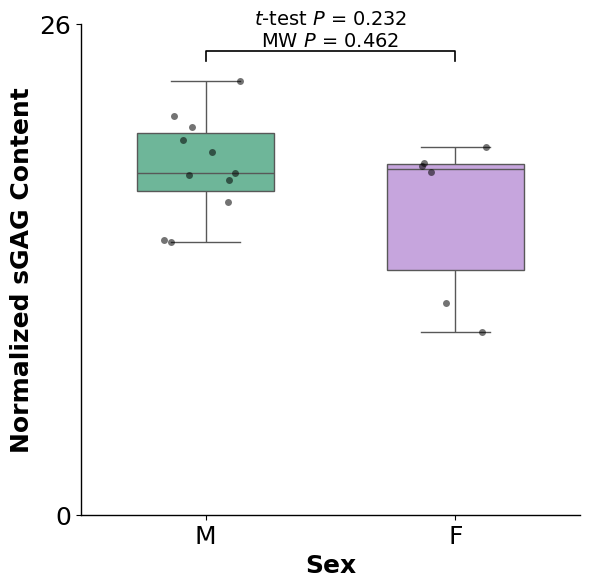

In [114]:
def plot_sex_boxplot(df, label, filename_suffix):
    df = df.copy()
    df['age'] = pd.to_numeric(df.get('age'), errors='coerce')
    plot_df = df.dropna(subset=['sex', 'normalized_value']).copy()
    plot_df = plot_df[plot_df['sex'].isin(['M', 'F'])]

    male_samples = plot_df[plot_df['sex'] == 'M']
    female_samples = plot_df[plot_df['sex'] == 'F']
    print(f"{label}: Male samples: {len(male_samples)}, Female samples: {len(female_samples)}")

    plt.figure(figsize=(6, 6))
    ax = sns.boxplot(
        data=plot_df,
        x='sex',
        y='normalized_value',
        order=['M', 'F'],
        palette={'M': color_M, 'F': color_F},
        showfliers=False,
        width=0.55
    )

    male_vals = plot_df.loc[plot_df['sex'] == 'M', 'normalized_value']
    female_vals = plot_df.loc[plot_df['sex'] == 'F', 'normalized_value']

    if len(male_vals) > 1 and len(female_vals) > 1:

        
        # Get t-test p-value for figure display
        t_stat, p_val = ttest_ind(male_vals, female_vals, equal_var=False, nan_policy='omit')
        u_stat, mw_p_val = mannwhitneyu(male_vals, female_vals, alternative='two-sided')

        figure_text = f"$\\it{{t}}$-test $\\it{{P}}$ = {p_val:.3f}\nMW $\\it{{P}}$ = {mw_p_val:.3f}"

        y_max_local = plot_df['normalized_value'].max()
        y_min_local = plot_df['normalized_value'].min()
        y_range_local = y_max_local - y_min_local if y_max_local > y_min_local else 1.0
        y = y_max_local + 0.08 * y_range_local
        h = 0.04 * y_range_local

        ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], c='black', lw=1.2)
        ax.text(0.5, y + h, figure_text, ha='center', va='bottom', fontsize=FONT_SIZE_small - 4)
    else:
        print(f"{label}: Not enough samples for t-test (need at least 2 per group).")

    sns.stripplot(
        data=plot_df,
        x='sex',
        y='normalized_value',
        order=['M', 'F'],
        color='black',
        alpha=0.55,
        jitter=0.18,
        size=5
    )

    plt.xlabel('Sex', fontsize=FONT_SIZE_small)
    plt.ylabel('Normalized sGAG Content', fontsize=FONT_SIZE_small)

    ax = plt.gca()
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    ax.set_xticks([0, xticks[-1]])
    ax.set_yticks([0, yticks[-1]])

    plt.tight_layout()
    save_fig(plt, f'DMMB_boxplot_by_sex_{filename_suffix}', output_path)
    plt.show()
    plt.close()

# Run for all, humans only, and apes only
plot_sex_boxplot(dmmb_ind_collapsed, 'All samples', 'all')
plot_sex_boxplot(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] == 'Human'], 'Human samples', 'human')
plot_sex_boxplot(dmmb_ind_collapsed[dmmb_ind_collapsed['species_name'] != 'Human'], 'Ape samples', 'ape')


# Biases between joints in humans

anatomical_region  sex
elbow              F       5
                   M       6
hip                F       2
                   M       1
knee               F       6
                   M       3
phalanges          F      11
                   M       9
shoulder           F       4
                   M       2
wrist              F       6
                   M       2
dtype: int64
elbow: t = -0.033, p = 9.742e-01
knee: t = -1.906, p = 1.086e-01
phalanges: t = 0.703, p = 4.923e-01
shoulder: t = 1.007, p = 3.800e-01
wrist: t = 0.130, p = 9.152e-01


/tmp/ipykernel_3459175/1905886205.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


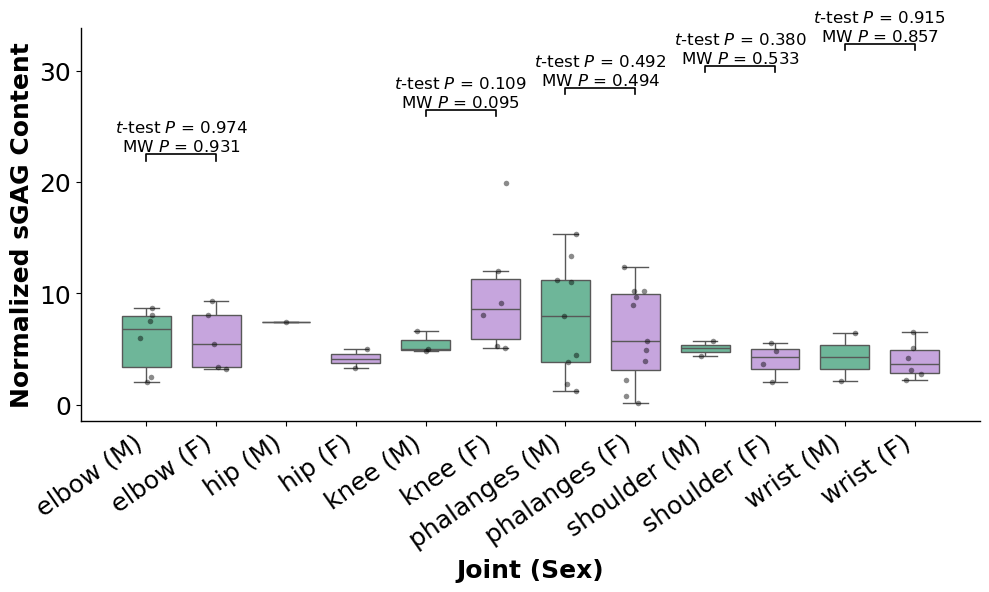

anatomical_region  sex
elbow              F      2
                   M      3
hip                M      2
knee               M      2
phalanges          F      1
shoulder           F      2
                   M      2
wrist              F      1
                   M      2
dtype: int64
elbow: t = 1.182, p = 4.415e-01
shoulder: t = -2.371, p = 2.477e-01


/tmp/ipykernel_3459175/1905886205.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


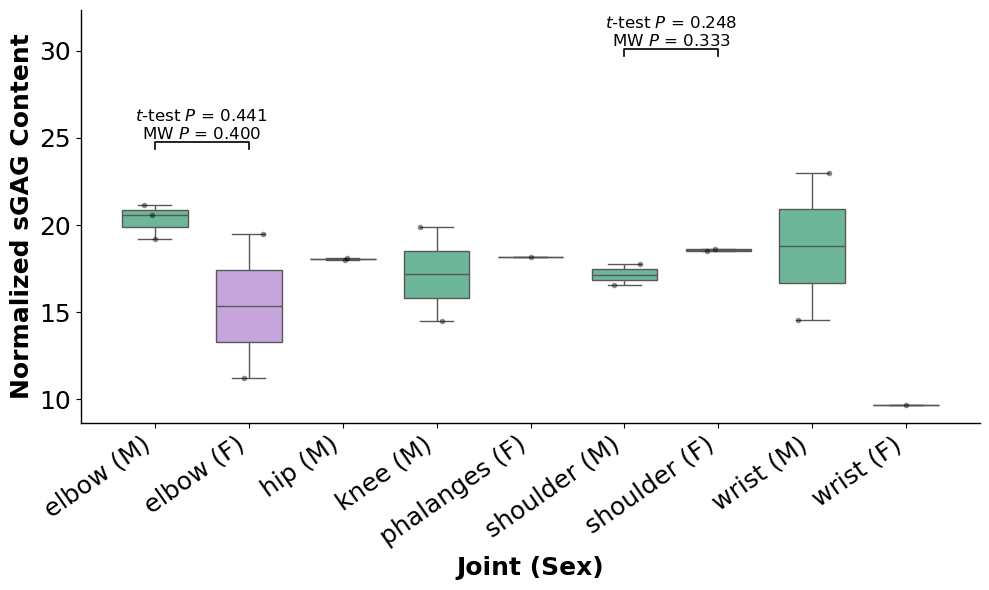

In [115]:
def plot_joint_sex_boxplot(df, subset_name, filename_suffix, species_mask):
    plot_df = df.loc[species_mask].copy()

    plot_df = plot_df.dropna(subset=['sex', 'normalized_value', 'anatomical_region']).copy()
    plot_df = plot_df[plot_df['sex'].isin(['M', 'F'])]

    if plot_df.empty:
        print(f"No data for {subset_name}")
        return

    region_order = sorted(plot_df['anatomical_region'].unique())
    sex_order = ['M', 'F']

    plot_df['joint_sex'] = plot_df['anatomical_region'] + ' (' + plot_df['sex'] + ')'
    joint_sex_order = [
        f"{joint} ({sex})"
        for joint in region_order
        for sex in sex_order
        if ((plot_df['anatomical_region'] == joint) & (plot_df['sex'] == sex)).any()
    ]

    pair_palette = {
        label: (color_M if label.endswith('(M)') else color_F)
        for label in joint_sex_order
    }

    print(plot_df.groupby(['anatomical_region', 'sex']).size())

    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(
        data=plot_df,
        x='joint_sex',
        y='normalized_value',
        order=joint_sex_order,
        palette=pair_palette,
        showfliers=False,
        width=0.7
    )

    sns.stripplot(
        data=plot_df,
        x='joint_sex',
        y='normalized_value',
        order=joint_sex_order,
        color='black',
        alpha=0.45,
        size=4,
        jitter=0.18
    )

    y_min = plot_df['normalized_value'].min()
    y_max = plot_df['normalized_value'].max()
    y_range = y_max - y_min if y_max > y_min else 1.0
    y_step = 0.10 * y_range

    for i, joint in enumerate(region_order):
        male = plot_df[(plot_df['anatomical_region'] == joint) & (plot_df['sex'] == 'M')]['normalized_value']
        female = plot_df[(plot_df['anatomical_region'] == joint) & (plot_df['sex'] == 'F')]['normalized_value']

        if len(male) > 1 and len(female) > 1:
            t_stat, p_val = ttest_ind(male, female, equal_var=False, nan_policy='omit')
            u_stat, mw_p_val = mannwhitneyu(male, female, alternative='two-sided')

            figure_text = figure_text = f"$\\it{{t}}$-test $\\it{{P}}$ = {p_val:.3f}\nMW $\\it{{P}}$ = {mw_p_val:.3f}"
            print(f"{joint}: t = {t_stat:.3f}, p = {p_val:.3e}")

            x1 = joint_sex_order.index(f"{joint} (M)")
            x2 = joint_sex_order.index(f"{joint} (F)")
            y = y_max + (i + 1) * y_step
            h = 0.03 * y_range

            plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c='black', lw=1.2)
            plt.text((x1 + x2) / 2, y + h, figure_text,
                     ha='center', va='bottom', fontsize=FONT_SIZE_small - 6)
            
    plt.xlabel('Joint (Sex)', fontsize=FONT_SIZE_small)
    plt.ylabel('Normalized sGAG Content', fontsize=FONT_SIZE_small)
    plt.xticks(rotation=35, ha='right')
    plt.ylim(top=y_max + (len(region_order) + 1) * y_step)
    plt.tight_layout()
    save_fig(plt, f'DMMB_boxplot_by_joint_and_sex_{filename_suffix}', output_path)
    plt.show()
    plt.close()


plot_joint_sex_boxplot(
    dmmb_ind_collapsed,
    'Human samples',
    'human',
    dmmb_ind_collapsed['species'] == 'H'
)

plot_joint_sex_boxplot(
    dmmb_ind_collapsed,
    'Non-human samples',
    'non_human',
    dmmb_ind_collapsed['species'] != 'H'
)


In [153]:
dmmb_ind_collapsed

,individual,anatomical_region,sample_id,origin_in_joint,species,age,sex,weight (g),DNA,description,notes,remove from analysis,species_name,Maximum longevity (yrs),age_adjustment_longevity,age_adjustment_charvet,normalized_value
0,240460,elbow,"70,80",capitulum_trochlea,H,51.0,M,0.037250,111.839336,Elbow - capitulum,None,NaN,Human,122.5,0.416327,51.000000,8.095497
1,240460,shoulder,90,humeral head,H,51.0,M,0.027400,89.673414,Shoulder - humeral head,None,NaN,Human,122.5,0.416327,51.000000,4.391243
2,240463,elbow,"75,85",capitulum_trochlea,H,80.0,F,0.029450,83.489818,Elbow - capitulum,None,NaN,Human,122.5,0.653061,80.000000,9.281992
3,240463,shoulder,95,humeral head,H,80.0,F,0.034500,137.531906,Shoulder - humeral head,None,NaN,Human,122.5,0.653061,80.000000,3.640044
4,240472,knee,117,tibia proximal,H,61.0,F,0.067100,110.946606,Tibia (articular surfae),"Breast cancer, lung cancer",NaN,Human,122.5,0.497959,61.000000,12.057652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,SN8,phalanges,"35,36,10A,9A",PIP_DIP_MCP,H,86.0,F,0.011025,25.112267,proximal interphalangial joint (PIP),None,NaN,Human,122.5,0.702041,86.000000,12.397168
70,SN9,elbow,42,trochlea,H,78.0,M,0.029200,57.334839,Elbow articular cartilage - trochlea,replaced sample 6 which evaporated,NaN,Human,122.5,0.636735,78.000000,6.008369
71,SN9,phalanges,"37,38,23A,24A",PIP_DIP_MCP,H,78.0,M,0.017825,37.367706,proximal interphalangial joint (PIP),None,NaN,Human,122.5,0.636735,78.000000,15.321917
72,Shoshi,phalanges,"48,49,50,51,52,53,43A",MCP_PIP_DIP,C,60.0,F,0.025043,27.526721,chimp - metacarpophalangeal joint (MCP),None,NaN,Chimpanzee,68.0,0.882353,76.458708,18.140548


# Comare full Joints

In [159]:
def compare_human_vs_nonhuman_by_region(df, anatomical_region, verbose=True, separate_subregions=True):
    region_df = df[df['anatomical_region'] == anatomical_region].copy()

    if region_df.empty:
        print(f"No samples found for anatomical_region='{anatomical_region}'")
        return None

    region_df['age_numeric'] = pd.to_numeric(region_df['age'], errors='coerce')
    region_df['group'] = np.where(region_df['species'] == 'H', 'Human', 'Ape')

    if verbose:
        print(f"Region: {anatomical_region}")
        print("=" * 80)
        print("\nSpecies counts:")
        print(region_df['species'].value_counts(dropna=False))

        if separate_subregions:
            print("\nSubregion counts:")
            print(region_df.groupby(['origin_in_joint', 'group']).size())
        else:
            for group_name, group_df in region_df.groupby('group'):
                print("\n" + "-" * 80)
                print(f"{group_name} group")
                print(f"n = {len(group_df)}")
                print("\nSpecies distribution:")
                print(group_df['species'].value_counts(dropna=False))
                print("\nSex distribution:")
                print(group_df['sex'].value_counts(dropna=False))

                age_vals = group_df['age_numeric'].dropna()
                if len(age_vals) > 0:
                    print("\nAge summary:")
                    print(age_vals.describe())
                else:
                    print("\nAge summary: no valid numeric ages")

    plt.figure(figsize=(6, 7))
    
    line_width = 4
    if separate_subregions:
        region_df['origin_in_joint'] = region_df['origin_in_joint'].astype(str)
        subregion_order = sorted(region_df['origin_in_joint'].dropna().unique())

        ax = sns.boxplot(
            data=region_df,
            x='origin_in_joint',
            y='normalized_value',
            hue='group',
            order=subregion_order,
            hue_order=['Human', 'Ape'],
            palette={'Human': '#2A96BA', 'Ape': '#F5AF4C'},
            showfliers=False,
            width=0.7,
            linewidth=line_width,
            boxprops={'edgecolor': '#A7A9AC', 'linewidth': 0},
            whiskerprops={'color': '#A7A9AC', 'linewidth': line_width},
            capprops={'color': '#A7A9AC', 'linewidth': line_width},
            medianprops={'color': '#A7A9AC', 'linewidth': line_width}
        )

    
        
        #ax = sns.boxplot(
        #    data=region_df,
        #    x='origin_in_joint',
        #    y='normalized_value',
        #    hue='group',
        #    order=subregion_order,
        #    hue_order=['Human', 'Ape'],
        #    palette={'Human': '#2A96BA', 'Ape': '#F5AF4C'},
        #    showfliers=False,
        #    width=0.7
        #)

        sns.stripplot(
            data=region_df,
            x='origin_in_joint',
            y='normalized_value',
            hue='group',
            order=subregion_order,
            hue_order=['Human', 'Ape'],
            dodge=True,
            color='black',
            alpha=0.45,
            jitter=0.15,
            size=4
        )

        if ax.legend_ is not None:
            ax.legend_.remove()

        y_max = region_df['normalized_value'].max()
        y_min = region_df['normalized_value'].min()
        y_range = y_max - y_min if y_max > y_min else 1.0

        for i, subregion in enumerate(subregion_order):
            human_vals = region_df[(region_df['origin_in_joint'] == subregion) & (region_df['group'] == 'Human')]['normalized_value']
            nonhuman_vals = region_df[(region_df['origin_in_joint'] == subregion) & (region_df['group'] == 'Ape')]['normalized_value']

            if len(human_vals) > 1 and len(nonhuman_vals) > 1:
                # Get t-test p-value for figure display
                t_stat, p_val = ttest_ind(human_vals, nonhuman_vals, equal_var=False, nan_policy='omit')
                u_stat, mw_p_val = mannwhitneyu(human_vals, nonhuman_vals, alternative='two-sided')

                figure_text = f"t-test p = {p_val:.3f}\nMW p = {mw_p_val:.3f}"

                x1, x2 = i - 0.2, i + 0.2
                y = y_max + (i + 1) * 0.08 * y_range
                h = 0.03 * y_range

                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c='black', lw=1.2)
                ax.text(i, y + h, figure_text, ha='center', va='bottom', fontsize=FONT_SIZE_small - 4)

        plt.xlabel('Subregion', fontsize=FONT_SIZE_big)
        plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')

    else:
        ax = sns.boxplot(
            data=region_df,
            x='group',
            y='normalized_value',
            order=['Human', 'Ape'],
            palette={'Human': '#2A96BA', 'Ape': '#F5AF4C'},
            showfliers=False,
            width=0.6,
            linewidth=line_width,
            boxprops={'edgecolor': '#A7A9AC', 'linewidth': 0},
            whiskerprops={'color': '#A7A9AC', 'linewidth': line_width},
            capprops={'color': '#A7A9AC', 'linewidth': line_width},
            medianprops={'color': '#A7A9AC', 'linewidth': line_width}
        )
        sns.stripplot(
            data=region_df,
            x='group',
            y='normalized_value',
            order=['Human', 'Ape'],
            hue='species',
            #color = 'black'
            alpha=0.5,
            jitter=0.18,
            size=10
        )

        human_vals = region_df.loc[region_df['group'] == 'Human', 'normalized_value']
        nonhuman_vals = region_df.loc[region_df['group'] == 'Ape', 'normalized_value']

        if len(human_vals) > 1 and len(nonhuman_vals) > 1:
            # Get t-test p-value for figure display
            t_stat, p_val = ttest_ind(human_vals, nonhuman_vals, equal_var=False, nan_policy='omit')
            u_stat, mw_p_val = mannwhitneyu(human_vals, nonhuman_vals, alternative='two-sided')

            figure_text = f"$\\it{{t}}$-test $\\it{{P}}$ = {p_val:.3f}\nMW $\\it{{P}}$ = {mw_p_val:.3f}"

            y_max = region_df['normalized_value'].max()
            y_min = region_df['normalized_value'].min()
            y_range = y_max - y_min if y_max > y_min else 1.0
            y = y_max + 0.08 * y_range
            h = 0.04 * y_range

            ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], c='black', lw=1.2)
            ax.text(0.5, y + h, figure_text, ha='center', va='bottom', fontsize=FONT_SIZE_small - 4)
        else:
            print("\nNot enough samples for t-test (need at least 2 per group).")

        plt.xlabel(f'{anatomical_region}', fontsize=FONT_SIZE_big)
    plt.ylabel('Normalized sGAG content', fontsize=FONT_SIZE_big)

    
    ax = plt.gca()
    ax.tick_params(axis='x', length=0)
    yticks = ax.get_yticks()
    ax.set_yticks([0, yticks[-1]])

    #legend = ax.get_legend()
    #if legend is not None:
    #    legend.remove()

    ax.spines['bottom'].set_visible(False)
    
    plt.tight_layout()
    #plt.show()

    return region_df

# Get unique anatomical regions and apply to all
regions = sorted(dmmb_ind_collapsed['anatomical_region'].unique())

# Iterate over each region
for region in regions:
    print(f"\n{'='*80}")
    print(f"REGION: {region}")
    print(f"{'='*80}\n")
    
    # Plot 1: with separate_subregions=True
    print(f"Plotting {region} with separate_subregions=True")
    compare_human_vs_nonhuman_by_region(dmmb_ind_collapsed, region, verbose=False, separate_subregions=True)
    save_fig(plt, f'{region}_separate_subregions', output_path)
    plt.close()
    
    # Plot 2: with separate_subregions=False
    print(f"Plotting {region} with separate_subregions=False")
    compare_human_vs_nonhuman_by_region(dmmb_ind_collapsed, region, verbose=False, separate_subregions=False)
    save_fig(plt, f'{region}_combined', output_path)
    plt.close()

print(f"\n{'='*80}")
print("All plots completed and saved to output_path")
print(f"{'='*80}")


REGION: elbow

Plotting elbow with separate_subregions=True


/tmp/ipykernel_3459175/4072732354.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/tmp/ipykernel_3459175/4072732354.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Plotting elbow with separate_subregions=False


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/tmp/ipykernel_3459175/4072732354.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(



REGION: hip

Plotting hip with separate_subregions=True


...


REGION: wrist

Plotting wrist with separate_subregions=True


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/tmp/ipykernel_3459175/4072732354.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Plotting wrist with separate_subregions=False


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



All plots completed and saved to output_path


# Phalanges

Before collapse:
  Rows: 70
  Sample_ids: 70

After collapse by individual + origin_in_joint:
  Rows: 50
  Unique individuals: 21

Phalanges subregions: ['MCP', 'PIP', 'DIP']
origin_in_joint  group    
DIP              Human        15
                 Non-human     1
MCP              Human        17
                 Non-human     1
PIP              Human        15
                 Non-human     1
dtype: int64
MCP: Ape value = 14.783, Human mean = 6.148 (SD=5.002), Param p = 8.428e-02, NP p = 0.158
PIP: Ape value = 21.126, Human mean = 9.014 (SD=5.020), Param p = 1.583e-02, NP p = 0.059
DIP: Ape value = 20.191, Human mean = 8.647 (SD=7.896), Param p = 1.437e-01, NP p = 0.176


/tmp/ipykernel_1457581/1789184270.py:68: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


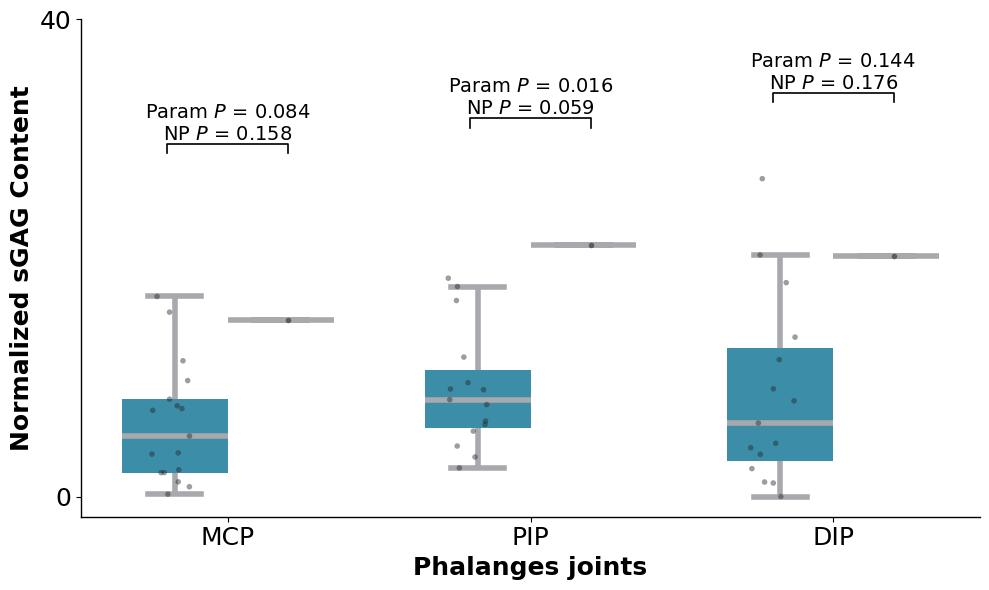

In [20]:
# Phalanges: all subregions compared (Human vs Non-human)
phalanges_df = dmmb_collapsed[dmmb_collapsed['anatomical_region'] == 'phalanges'].copy()

# Desired subregion order (left -> right)
desired_order = ['MCP', 'PIP', 'DIP']
subregion_order = [s for s in desired_order if s in phalanges_df['origin_in_joint'].dropna().unique()]

if not phalanges_df.empty:
    phalanges_df['group'] = np.where(phalanges_df['species'] == 'H', 'Human', 'Non-human')
    phalanges_df['origin_in_joint'] = phalanges_df['origin_in_joint'].astype(str)
    
    # Collapse by individual + origin_in_joint
    print("Before collapse:")
    print(f"  Rows: {len(phalanges_df)}")
    print(f"  Sample_ids: {phalanges_df['sample_id'].nunique()}")
    
    collapse_cols_phal = [c for c in phalanges_df.columns if c not in ['sample_id', 'notes', 'description', 'normalized_value', 'weight (g)', 'DNA']]
    
    # aggregation map for phalanges collapse
    agg_map_phal = {}
    for col in phalanges_df.columns:
        if col in ['sample_id', 'notes', 'description']:
            agg_map_phal[col] = lambda x: ','.join(map(str, x.dropna().unique()))
        elif col in ['normalized_value', 'weight (g)', 'DNA']:
            agg_map_phal[col] = 'mean'
        else:
            agg_map_phal[col] = 'first'
    
    phalanges_df = (
        phalanges_df
        .groupby(['individual', 'origin_in_joint'], as_index=False)
        .agg(agg_map_phal)
    )
    
    # Reorder columns to keep individual and origin_in_joint first
    cols_order_phal = ['individual', 'origin_in_joint'] + [c for c in phalanges_df.columns if c not in ['individual', 'origin_in_joint']]
    phalanges_df = phalanges_df[cols_order_phal]
    
    print("\nAfter collapse by individual + origin_in_joint:")
    print(f"  Rows: {len(phalanges_df)}")
    print(f"  Unique individuals: {phalanges_df['individual'].nunique()}")
    
    # Get subregion order - use desired order (MCP, PIP, DIP from left to right)
    subregion_order = [s for s in desired_order if s in phalanges_df['origin_in_joint'].dropna().unique()]
    
    print(f"\nPhalanges subregions: {subregion_order}")
    print(phalanges_df.groupby(['origin_in_joint', 'group']).size())
    
    line_width = 4
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(
        data=phalanges_df,
        x='origin_in_joint',
        y='normalized_value',
        hue='group',
        order=subregion_order,
        hue_order=['Human', 'Non-human'],
        palette={'Human': '#2A96BA', 'Non-human': '#F5AF4C'},
        showfliers=False,
        width=0.7,
        linewidth=line_width,
        boxprops={'edgecolor': '#A7A9AC', 'linewidth': 0},
        whiskerprops={'color': '#A7A9AC', 'linewidth': line_width},
        capprops={'color': '#A7A9AC', 'linewidth': line_width},
        medianprops={'color': '#A7A9AC', 'linewidth': line_width}
    )
    
    sns.stripplot(
        data=phalanges_df,
        x='origin_in_joint',
        y='normalized_value',
        hue='group',
        order=subregion_order,
        hue_order=['Human', 'Non-human'],
        dodge=True,
        color='black',
        alpha=0.45,
        jitter=0.15,
        size=4
    )
    
    if ax.legend_ is not None:
        ax.legend_.remove()
    
    y_max = phalanges_df['normalized_value'].max()
    y_min = phalanges_df['normalized_value'].min()
    y_range = y_max - y_min if y_max > y_min else 1.0
    
    for i, subregion in enumerate(subregion_order):
        human_vals = phalanges_df[(phalanges_df['origin_in_joint'] == subregion) & (phalanges_df['group'] == 'Human')]['normalized_value']
        nonhuman_vals = phalanges_df[(phalanges_df['origin_in_joint'] == subregion) & (phalanges_df['group'] == 'Non-human')]['normalized_value']
        
        if len(human_vals) > 1:
            if len(nonhuman_vals) > 1:
                # Standard t-test and Mann-Whitney U test
                t_stat, p_val = ttest_ind(human_vals, nonhuman_vals, equal_var=False, nan_policy='omit')
                u_stat, mw_p_val = mannwhitneyu(human_vals, nonhuman_vals, alternative='two-sided')
                
                figure_text = f"t-test p = {p_val:.3f}\nMW p = {mw_p_val:.3f}"
                print(f"{subregion}: t = {t_stat:.3f}, p = {p_val:.3e}")
                
                x1, x2 = i - 0.2, i + 0.2
                y = y_max + (i + 1) * 0.08 * y_range
                h = 0.03 * y_range
                
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c='black', lw=1.2)
                ax.text(i, y + h, figure_text, ha='center', va='bottom', fontsize=FONT_SIZE_small - 4)
            
            elif len(nonhuman_vals) == 1:
                # Single non-human (ape) value - use parametric and non-parametric tests
                ape_val = nonhuman_vals.values[0]
                human_mean = human_vals.mean()
                human_std = human_vals.std()
                
                # Parametric: z-score based on normal distribution assumption
                if human_std > 0:
                    z_score = (ape_val - human_mean) / human_std
                    # Two-tailed p-value from normal distribution
                    from scipy.stats import norm
                    param_p_val = 2 * (1 - norm.cdf(abs(z_score)))
                else:
                    param_p_val = 1.0
                
                # Non-parametric: rank-based p-value (empirical)
                # Count how many human values are more extreme than the ape value
                all_vals = np.concatenate([human_vals.values, [ape_val]])
                n_human = len(human_vals)
                
                # Calculate empirical p-value: what fraction of permutations would be as extreme
                # Simpler approach: count how many human values are on the opposite side of median
                less_than_ape = (human_vals < ape_val).sum()
                greater_than_ape = (human_vals > ape_val).sum()
                n_extreme = min(less_than_ape, greater_than_ape)
                # Two-tailed: probability of observing ape value as extreme or more
                nonparam_p_val = (n_extreme + 1) / (n_human + 2)  # +2 for continuity correction
                
                figure_text = f"Param $\\it{{P}}$ = {param_p_val:.3f}\nNP $\\it{{P}}$ = {nonparam_p_val:.3f}"
                print(f"{subregion}: Ape value = {ape_val:.3f}, Human mean = {human_mean:.3f} (SD={human_std:.3f}), Param p = {param_p_val:.3e}, NP p = {nonparam_p_val:.3f}")
                
                x1, x2 = i - 0.2, i + 0.2
                y = y_max + (i + 1) * 0.08 * y_range
                h = 0.03 * y_range
                
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c='black', lw=1.2)
                ax.text(i, y + h, figure_text, ha='center', va='bottom', fontsize=FONT_SIZE_small - 4)




    plt.xlabel('Phalanges joints', fontsize=FONT_SIZE_small)
    plt.ylabel('Normalized sGAG Content', fontsize=FONT_SIZE_small)
    plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')

    ax = plt.gca()
    yticks = ax.get_yticks()
    ax.set_yticks([0, yticks[-1]])
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
        
    plt.tight_layout()
    save_fig(plt, 'DMMB_boxplot_phalanges_all_subregions', output_path)
    plt.show()
else:
    print("No phalanges data found")

FOLD CHANGE ANALYSIS: Ape median / Human median for each phalanges joint

MCP:
  Human median: 5.076
  Ape median:   14.783
  Fold change:  2.913x
  Log2 FC:      1.542

PIP:
  Human median: 8.124
  Ape median:   21.126
  Fold change:  2.600x
  Log2 FC:      1.379

DIP:
  Human median: 6.161
  Ape median:   20.191
  Fold change:  3.277x
  Log2 FC:      1.713

Joint  Human Median  Ape Median  Fold Change (Ape/Human)  Log2 Fold Change
  MCP      5.075561   14.783294                 2.912643          1.542329
  PIP      8.123849   21.125940                 2.600484          1.378780
  DIP      6.160710   20.191035                 3.277388          1.712546


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


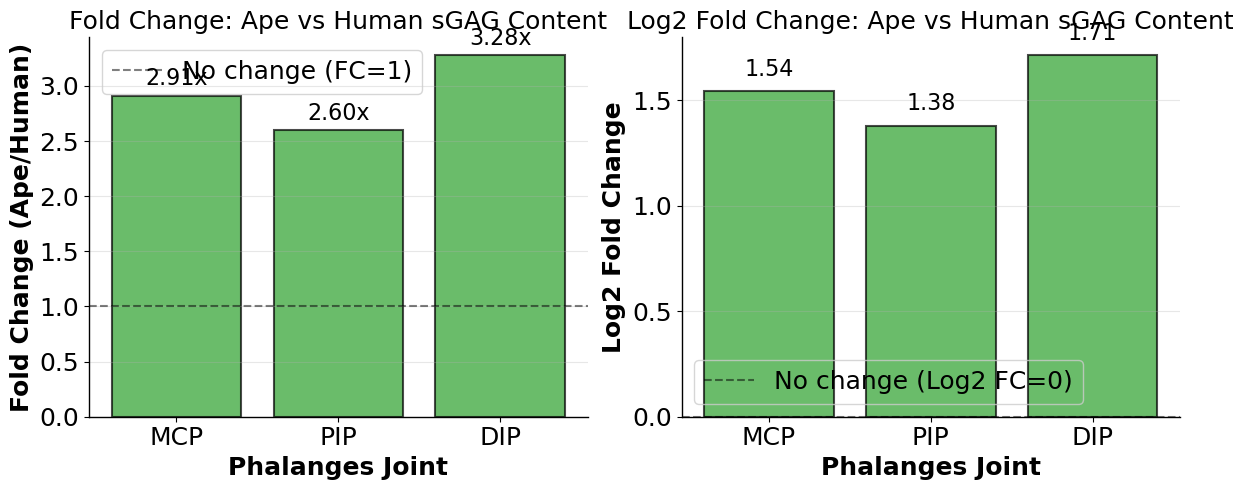

In [100]:
# Calculate fold change between ape and human medians for each joint
print("=" * 80)
print("FOLD CHANGE ANALYSIS: Ape median / Human median for each phalanges joint")
print("=" * 80)

fold_change_data = []

for subregion in subregion_order:
    human_vals = phalanges_df[(phalanges_df['origin_in_joint'] == subregion) & (phalanges_df['group'] == 'Human')]['normalized_value']
    ape_vals = phalanges_df[(phalanges_df['origin_in_joint'] == subregion) & (phalanges_df['group'] == 'Non-human')]['normalized_value']
    
    if len(human_vals) > 0 and len(ape_vals) > 0:
        human_median = human_vals.median()
        ape_median = ape_vals.median()
        fold_change = ape_median / human_median if human_median > 0 else np.nan
        
        fold_change_data.append({
            'Joint': subregion,
            'Human Median': human_median,
            'Ape Median': ape_median,
            'Fold Change (Ape/Human)': fold_change,
            'Log2 Fold Change': np.log2(fold_change) if fold_change > 0 else np.nan
        })
        
        print(f"\n{subregion}:")
        print(f"  Human median: {human_median:.3f}")
        print(f"  Ape median:   {ape_median:.3f}")
        print(f"  Fold change:  {fold_change:.3f}x")
        print(f"  Log2 FC:      {np.log2(fold_change):.3f}")

fold_change_df = pd.DataFrame(fold_change_data)
print("\n" + "=" * 80)
print(fold_change_df.to_string(index=False))
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Fold change (linear scale)
ax1 = axes[0]
colors_fc = ['#2CA02C' if fc >= 1 else '#D62728' for fc in fold_change_df['Fold Change (Ape/Human)']]
ax1.bar(fold_change_df['Joint'], fold_change_df['Fold Change (Ape/Human)'], 
        color=colors_fc, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axhline(y=1, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No change (FC=1)')
ax1.set_ylabel('Fold Change (Ape/Human)', fontsize=FONT_SIZE_small)
ax1.set_xlabel('Phalanges Joint', fontsize=FONT_SIZE_small)
ax1.set_title('Fold Change: Ape vs Human sGAG Content', fontsize=FONT_SIZE_small)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (joint, fc) in enumerate(zip(fold_change_df['Joint'], fold_change_df['Fold Change (Ape/Human)'])):
    ax1.text(i, fc + 0.05, f'{fc:.2f}x', ha='center', va='bottom', fontsize=FONT_SIZE_small - 2)

# Plot 2: Log2 fold change
ax2 = axes[1]
colors_log2 = ['#2CA02C' if lfc >= 0 else '#D62728' for lfc in fold_change_df['Log2 Fold Change']]
ax2.bar(fold_change_df['Joint'], fold_change_df['Log2 Fold Change'], 
        color=colors_log2, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No change (Log2 FC=0)')
ax2.set_ylabel('Log2 Fold Change', fontsize=FONT_SIZE_small)
ax2.set_xlabel('Phalanges Joint', fontsize=FONT_SIZE_small)
ax2.set_title('Log2 Fold Change: Ape vs Human sGAG Content', fontsize=FONT_SIZE_small)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (joint, lfc) in enumerate(zip(fold_change_df['Joint'], fold_change_df['Log2 Fold Change'])):
    y_pos = lfc + (0.05 if lfc >= 0 else -0.15)
    ax2.text(i, y_pos, f'{lfc:.2f}', ha='center', va='bottom' if lfc >= 0 else 'top', fontsize=FONT_SIZE_small - 2)

plt.tight_layout()
save_fig(plt, 'DMMB_foldchange_ape_vs_human_phalanges', output_path)
plt.show()

FOLD CHANGE ANALYSIS: Ape median / Human median for all anatomical regions

elbow:
  Human n=11, median: 6.008
  Ape n=5, median:   19.510
  Fold change:  3.247x
  Log2 FC:      1.699

hip:
  Human n=3, median: 4.977
  Ape n=2, median:   18.046
  Fold change:  3.626x
  Log2 FC:      1.858

knee:
  Human n=9, median: 6.638
  Ape n=2, median:   17.167
  Fold change:  2.586x
  Log2 FC:      1.371

phalanges:
  Human n=20, median: 6.822
  Ape n=1, median:   18.141
  Fold change:  2.659x
  Log2 FC:      1.411

shoulder:
  Human n=6, median: 4.633
  Ape n=4, median:   18.126
  Fold change:  3.912x
  Log2 FC:      1.968

wrist:
  Human n=8, median: 3.657
  Ape n=3, median:   14.549
  Fold change:  3.978x
  Log2 FC:      1.992

Anatomical Region  Human n  Ape n  Human Median  Ape Median  Fold Change (Ape/Human)  Log2 Fold Change
            wrist        8      3      3.657056   14.549333                 3.978428          1.992198
         shoulder        6      4      4.633220   18.125707     

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


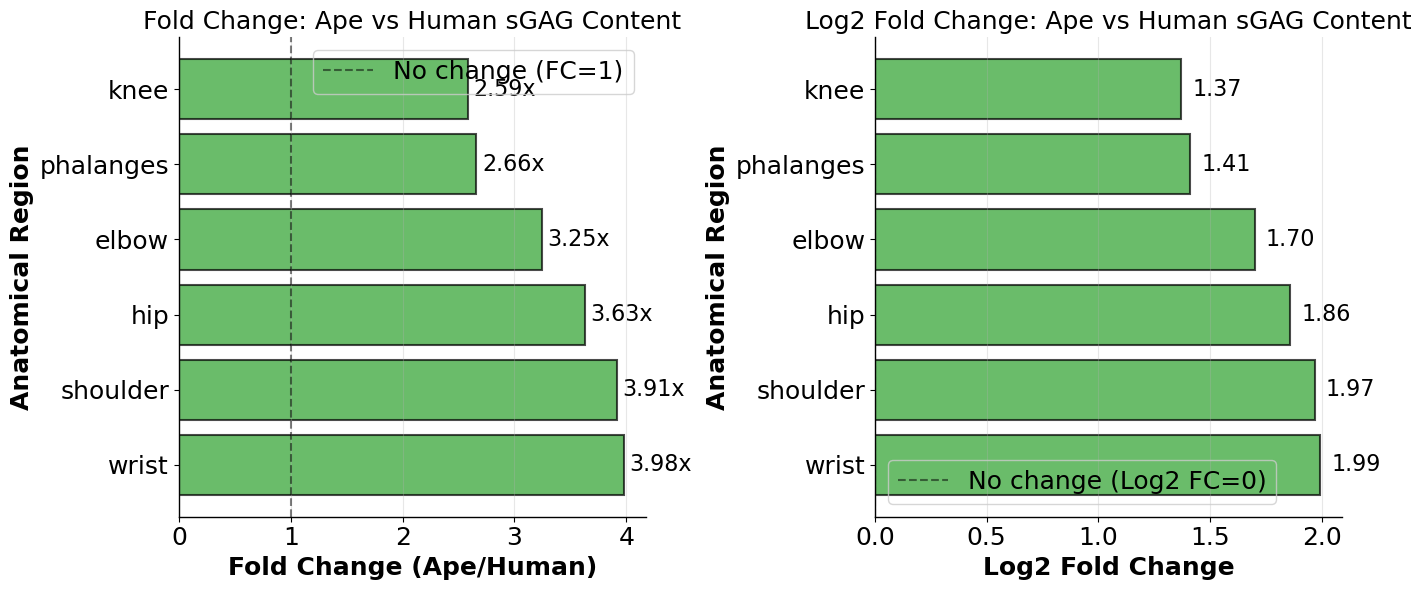

In [102]:
# Calculate fold change between ape and human medians for ALL joints (anatomical regions)
print("=" * 80)
print("FOLD CHANGE ANALYSIS: Ape median / Human median for all anatomical regions")
print("=" * 80)

fold_change_all_data = []

# Prepare data with group labels
all_regions_df = dmmb_ind_collapsed.copy()
all_regions_df['group'] = np.where(all_regions_df['species'] == 'H', 'Human', 'Non-human')

# Get all anatomical regions
all_regions = sorted(all_regions_df['anatomical_region'].dropna().unique())

for region in all_regions:
    region_data = all_regions_df[all_regions_df['anatomical_region'] == region]
    
    human_vals = region_data[region_data['group'] == 'Human']['normalized_value']
    ape_vals = region_data[region_data['group'] == 'Non-human']['normalized_value']
    
    if len(human_vals) > 0 and len(ape_vals) > 0:
        human_median = human_vals.median()
        ape_median = ape_vals.median()
        fold_change = ape_median / human_median if human_median > 0 else np.nan
        
        fold_change_all_data.append({
            'Anatomical Region': region,
            'Human n': len(human_vals),
            'Ape n': len(ape_vals),
            'Human Median': human_median,
            'Ape Median': ape_median,
            'Fold Change (Ape/Human)': fold_change,
            'Log2 Fold Change': np.log2(fold_change) if fold_change > 0 else np.nan
        })
        
        print(f"\n{region}:")
        print(f"  Human n={len(human_vals)}, median: {human_median:.3f}")
        print(f"  Ape n={len(ape_vals)}, median:   {ape_median:.3f}")
        print(f"  Fold change:  {fold_change:.3f}x")
        print(f"  Log2 FC:      {np.log2(fold_change):.3f}")

fold_change_all_df = pd.DataFrame(fold_change_all_data)
fold_change_all_df = fold_change_all_df.sort_values('Fold Change (Ape/Human)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print(fold_change_all_df.to_string(index=False))
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Fold change (linear scale)
ax1 = axes[0]
colors_fc = ['#2CA02C' if fc >= 1 else '#D62728' for fc in fold_change_all_df['Fold Change (Ape/Human)']]
bars1 = ax1.barh(fold_change_all_df['Anatomical Region'], fold_change_all_df['Fold Change (Ape/Human)'], 
                  color=colors_fc, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axvline(x=1, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No change (FC=1)')
ax1.set_xlabel('Fold Change (Ape/Human)', fontsize=FONT_SIZE_small)
ax1.set_ylabel('Anatomical Region', fontsize=FONT_SIZE_small)
ax1.set_title('Fold Change: Ape vs Human sGAG Content', fontsize=FONT_SIZE_small)
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (region, fc) in enumerate(zip(fold_change_all_df['Anatomical Region'], fold_change_all_df['Fold Change (Ape/Human)'])):
    ax1.text(fc + 0.05, i, f'{fc:.2f}x', ha='left', va='center', fontsize=FONT_SIZE_small - 2)

# Plot 2: Log2 fold change
ax2 = axes[1]
colors_log2 = ['#2CA02C' if lfc >= 0 else '#D62728' for lfc in fold_change_all_df['Log2 Fold Change']]
bars2 = ax2.barh(fold_change_all_df['Anatomical Region'], fold_change_all_df['Log2 Fold Change'], 
                  color=colors_log2, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No change (Log2 FC=0)')
ax2.set_xlabel('Log2 Fold Change', fontsize=FONT_SIZE_small)
ax2.set_ylabel('Anatomical Region', fontsize=FONT_SIZE_small)
ax2.set_title('Log2 Fold Change: Ape vs Human sGAG Content', fontsize=FONT_SIZE_small)
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (region, lfc) in enumerate(zip(fold_change_all_df['Anatomical Region'], fold_change_all_df['Log2 Fold Change'])):
    x_pos = lfc + (0.05 if lfc >= 0 else -0.15)
    ax2.text(x_pos, i, f'{lfc:.2f}', ha='left' if lfc >= 0 else 'right', va='center', fontsize=FONT_SIZE_small - 2)

plt.tight_layout()
save_fig(plt, 'DMMB_foldchange_ape_vs_human_all_joints', output_path)
plt.show()

In [27]:
from scipy.stats import combine_pvalues, norm
from statsmodels.stats.multitest import multipletests

print("=" * 100)
print("FISHER'S METHOD: Combining p-values from 8 joints using Fisher's combined probability test")
print("=" * 100)

# Initialize data structures
pvals_all = []
pval_results = []

# ============================================================================
# PART 1: Calculate p-values for phalanges subregions (PIP, MCP, DIP)
# ============================================================================
print("\n[1] Phalanges subregions (PIP, MCP, DIP)")
print("-" * 100)

phalanges_joints = ['PIP', 'MCP', 'DIP']

for subregion in phalanges_joints:
    human_vals = phalanges_df[(phalanges_df['origin_in_joint'] == subregion) & (phalanges_df['species'] == 'H')]['normalized_value']
    nonhuman_vals = phalanges_df[(phalanges_df['origin_in_joint'] == subregion) & (phalanges_df['species'] != 'H')]['normalized_value']
    
    if len(human_vals) > 1:
        if len(nonhuman_vals) > 1:
            # Standard t-test (multiple non-human values)
            t_stat, p_val = ttest_ind(human_vals, nonhuman_vals, equal_var=False, nan_policy='omit')
            
            pvals_all.append(p_val)
            pval_results.append({
                'Joint': f'Phalanges: {subregion}',
                'Human n': len(human_vals),
                'Non-human n': len(nonhuman_vals),
                'Test Type': 't-test',
                't-statistic': t_stat,
                'p-value': p_val
            })
            
            print(f"  {subregion:10s}: n_H={len(human_vals)}, n_NH={len(nonhuman_vals)}, t={t_stat:7.3f}, p={p_val:.4e} [t-test]")
        
        elif len(nonhuman_vals) == 1:
            # Single non-human value - use parametric Z-score approach
            ape_val = nonhuman_vals.values[0]
            human_mean = human_vals.mean()
            human_std = human_vals.std()
            
            # Parametric: z-score based on normal distribution assumption
            if human_std > 0:
                z_score = (ape_val - human_mean) / human_std
                # Two-tailed p-value from normal distribution
                p_val = 2 * (1 - norm.cdf(abs(z_score)))
            else:
                p_val = 1.0
            
            pvals_all.append(p_val)
            pval_results.append({
                'Joint': f'Phalanges: {subregion}',
                'Human n': len(human_vals),
                'Non-human n': len(nonhuman_vals),
                'Test Type': 'Z-score (param)',
                't-statistic': z_score if human_std > 0 else np.nan,
                'p-value': p_val
            })
            
            print(f"  {subregion:10s}: n_H={len(human_vals)}, n_NH={len(nonhuman_vals)}, z={z_score:7.3f}, p={p_val:.4e} [Z-score]")
        else:
            print(f"  {subregion:10s}: Skipped (insufficient non-human samples: n_NH={len(nonhuman_vals)})")
    else:
        print(f"  {subregion:10s}: Skipped (insufficient human samples: n_H={len(human_vals)})")

# ============================================================================
# PART 2: Calculate p-values for other anatomical regions
# ============================================================================
print("\n[2] Other anatomical regions (Wrist, Shoulder, Hip, Elbow, Knee)")
print("-" * 100)

other_regions = ['wrist', 'shoulder', 'hip', 'elbow', 'knee']

for region in other_regions:
    region_data = dmmb_ind_collapsed[dmmb_ind_collapsed['anatomical_region'] == region]
    
    human_vals = region_data[region_data['species'] == 'H']['normalized_value']
    nonhuman_vals = region_data[region_data['species'] != 'H']['normalized_value']
    
    if len(human_vals) > 1 and len(nonhuman_vals) > 1:
        # Calculate t-test p-value
        t_stat, p_val = ttest_ind(human_vals, nonhuman_vals, equal_var=False, nan_policy='omit')
        
        pvals_all.append(p_val)
        pval_results.append({
            'Joint': region.capitalize(),
            'Human n': len(human_vals),
            'Non-human n': len(nonhuman_vals),
            'Test Type': 't-test',
            't-statistic': t_stat,
            'p-value': p_val
        })
        
        print(f"  {region.capitalize():10s}: n_H={len(human_vals)}, n_NH={len(nonhuman_vals)}, t={t_stat:7.3f}, p={p_val:.4e} [t-test]")
    else:
        print(f"  {region.capitalize():10s}: Skipped (insufficient samples: n_H={len(human_vals)}, n_NH={len(nonhuman_vals)})")

# ============================================================================
# PART 3: Apply Fisher's method to combine p-values
# ============================================================================
print("\n" + "=" * 100)
print("FISHER'S COMBINED PROBABILITY TEST")
print("=" * 100)

if len(pvals_all) > 0:
    # Combine p-values using Fisher's method
    combined_stat, combined_p_val = combine_pvalues(pvals_all, method='fisher')
    
    # Create results dataframe
    pval_results_df = pd.DataFrame(pval_results)
    
    # Calculate Benjamini-Hochberg FDR correction
    reject, fdr_pvals, alpha_sidak, alpha_bonf = multipletests(pval_results_df['p-value'], method='fdr_bh')
    pval_results_df['BH FDR q-value'] = fdr_pvals
    
    print(f"\nNumber of joints analyzed: {len(pvals_all)}")
    print("\nP-values per joint:")
    print("-" * 100)
    print(pval_results_df.to_string(index=False))
    
    print("\n" + "=" * 100)
    print(f"COMBINED RESULTS (Fisher's Method):")
    print("=" * 100)
    print(f"Test Statistic (chi-square): {combined_stat:.4f}")
    print(f"Combined p-value: {combined_p_val:.4e}")
    print(f"Degrees of freedom: {2 * len(pvals_all)}")
    print("=" * 100)
    
else:
    print("\nERROR: No valid p-values were calculated.")

FISHER'S METHOD: Combining p-values from 8 joints using Fisher's combined probability test

[1] Phalanges subregions (PIP, MCP, DIP)
----------------------------------------------------------------------------------------------------
  PIP       : n_H=15, n_NH=1, z=  2.413, p=1.5828e-02 [Z-score]
  MCP       : n_H=17, n_NH=1, z=  1.726, p=8.4278e-02 [Z-score]
  DIP       : n_H=15, n_NH=1, z=  1.462, p=1.4371e-01 [Z-score]

[2] Other anatomical regions (Wrist, Shoulder, Hip, Elbow, Knee)
----------------------------------------------------------------------------------------------------
  Wrist     : n_H=8, n_NH=3, t= -2.961, p=9.1652e-02 [t-test]
  Shoulder  : n_H=6, n_NH=4, t=-18.270, p=8.9404e-08 [t-test]
  Hip       : n_H=3, n_NH=2, t=-10.694, p=8.5451e-03 [t-test]
  Elbow     : n_H=11, n_NH=5, t= -6.311, p=9.1931e-04 [t-test]
  Knee      : n_H=9, n_NH=2, t= -2.758, p=1.1926e-01 [t-test]

FISHER'S COMBINED PROBABILITY TEST

Number of joints analyzed: 8

P-values per joint:
---------